# Chemically-Informed Bayesian Optimization for Cu₃VS₄ Nanoparticle Synthesis

## A Surrogate Model Approach with Domain Knowledge Integration

---

### Overview

This notebook implements a **hierarchical Bayesian optimization framework** that combines:

1. **Raw synthesis parameters** (what you control in the lab)
2. **Chemically-derived features** (stoichiometric ratios, concentrations)
3. **Proper uncertainty quantification** (GP posteriors with calibration checks)
4. **Interpretability tools** (Partial Dependence Plots for mechanism insight)

### Problem Formulation

**Goal**: Given a target particle size, find synthesis conditions that:
- Hit the target size (within tolerance)
- Minimize GSD (toward 1.0 = monodisperse)
- Maximize Squareness (toward 1.0 = cubic)
- Ensure phase purity and cubic polymorph

### Hierarchical Structure

```
Level 1: Feasibility Classification
    ├── HasProduct (did reaction work?)
    ├── PhasePure (single phase Cu₃VS₄?)
    └── IsCubic (cubic polymorph?)

Level 2: Property Regression (conditional on feasibility)
    ├── Size (nm)
    ├── GSD (geometric standard deviation)
    └── Squareness (morphology metric)
```

### Chemical Features

| Feature | Formula | Chemical Meaning |
|---------|---------|------------------|
| Cu_V_ratio | CuI / VOacac | Stoichiometry (target = 3.0 for Cu₃VS₄) |
| S_Metal_ratio | DDT_mmol / (CuI + VOacac) | Sulfur excess driving nucleation |
| Ligand_Metal_ratio | OAm_mmol / (CuI + VOacac) | Surface capping density |
| Metal_Conc | (CuI + VOacac) / V_total | Total metal concentration (mM) |
| log_Time | log₁₀(Time) | Linearized reaction kinetics |

### References
- Jones et al. (1998) - Efficient Global Optimization
- Gelbart et al. (2014) - Bayesian Optimization with Unknown Constraints
- Raccuglia et al. (2016) Nature - ML-assisted materials discovery

---

In [16]:
# =============================================================================
# IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Any, Callable
import warnings
from copy import deepcopy

# ML imports
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor, GaussianProcessClassifier
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C, WhiteKernel
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Statistical imports
from scipy.stats import norm, spearmanr
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube

from datetime import datetime

# Import from the Cu3VS4 optimizer module
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
from cuvs_optimizer import (
    Cu3VS4Optimizer,
    raw_to_chemical_features,
    chemical_to_raw_features,
    add_chemical_features,
    compute_feature_bounds,
    make_gp_regressor,
    make_gp_classifier,
    expected_improvement,
    prob_in_interval,
    latin_hypercube_sample,
    calculate_objective_weights,
    loo_cv,
    RAW_FACTORS,
    CHEM_FEATURES,
    CHEM_FEATURES_BASIC,
    CHEM_FEATURES_ENHANCED,
    HYBRID_FEATURES,
    RAW_BOUNDS,
    OBJECTIVES,
    FEAS_COLS,
    POLYMORPH_COL,
    CUBIC_LABEL,
    CUI_MMOL,
    TOTAL_VOLUME_ML,
    DDT_MMOL_PER_ML,
    OAM_MMOL_PER_ML,
    ENHANCED_FEATURE_CONFIG,
    CURRENT_PRECURSORS,
)

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Imports successful!")
print("✓ Using Cu3VS4Optimizer from cuvs_optimizer module")


Imports successful!
✓ Using Cu3VS4Optimizer from cuvs_optimizer module


In [17]:
# =============================================================================
# PUBLICATION STYLE
# =============================================================================
def set_publication_style():
    plt.rcParams.update({
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'figure.figsize': (6, 4),
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'font.family': 'sans-serif',
    })

set_publication_style()

COLORS = {
    'primary': '#2E86AB',
    'secondary': '#A23B72', 
    'tertiary': '#F18F01',
    'success': '#2E8B57',
    'warning': '#E63946',
    'neutral': '#6C757D',
}

---
## 1. Configuration

Edit `DATA_PATH` and system constants for your setup.

In [18]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Data path - supports relative path or environment variable override
from pathlib import Path
import os
import sys

# Add parent directory to path for chemical_constants import
sys.path.insert(0, str(Path("..").resolve()))
try:
    import chemical_constants as chem_const
    CHEM_CONSTANTS_AVAILABLE = True
    print("✓ Chemical constants module loaded")
except ImportError:
    CHEM_CONSTANTS_AVAILABLE = False
    print("⚠ Chemical constants module not found - enhanced features disabled")

# Data path resolution: Use environment variable or relative path
# Priority: 1) Environment variable, 2) Relative path from notebook, 3) Relative from project root
env_path = os.getenv("CUVS_DATA_PATH")
if env_path:
    DATA_PATH = Path(env_path).expanduser().resolve()
elif (Path("..") / "Data" / "COMPLETE_CUVS_DATA_SIDE2.csv").exists():
    DATA_PATH = (Path("..") / "Data" / "COMPLETE_CUVS_DATA_SIDE2.csv").resolve()
elif (Path("Data") / "COMPLETE_CUVS_DATA_SIDE2.csv").exists():
    DATA_PATH = (Path("Data") / "COMPLETE_CUVS_DATA_SIDE2.csv").resolve()
else:
    raise FileNotFoundError(
        f"Data file not found. Please:\n"
        f"  1. Set CUVS_DATA_PATH environment variable, OR\n"
        f"  2. Ensure data file is at: Data/COMPLETE_CUVS_DATA_SIDE2.csv\n"
        f"Current working directory: {Path.cwd()}"
    )

print(f"Using data file: {DATA_PATH}")

# =============================================================================
# OUTPUT DIRECTORY CONFIGURATION
# =============================================================================
# All outputs (figures, CSVs) will be saved here
# Default: Outputs/ folder at project root (one level up from Notebooks/)
OUTPUT_DIR = Path("..") / "Outputs"
# Alternative: Use absolute path or create new folder
# OUTPUT_DIR = Path("/Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Outputs")

# Create output directory if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR.resolve()}")

# =============================================================================
# SYSTEM CONSTANTS
# =============================================================================
CUI_MMOL = 0.25              # Fixed CuI amount (mmol)
TOTAL_VOLUME_ML = 12.0       # Fixed total volume (mL)
DDT_MMOL_PER_ML = 4.17       # DDT conversion (MW=202.4, ρ=0.845)
OAM_MMOL_PER_ML = 3.04       # OAm conversion (MW=267.5, ρ=0.813)

# =============================================================================
# FACTOR DEFINITIONS
# =============================================================================
RAW_FACTORS = ["Temp", "Time", "VOacac", "DDT", "OAm"]

# Chemical features derived from raw factors (BASIC)
CHEM_FEATURES_BASIC = [
    "Cu_V_ratio",         # Stoichiometry
    "S_Metal_ratio",      # Sulfur excess
    "Ligand_Metal_ratio", # Capping density
    "Metal_Conc",         # Total metal concentration
    "log_Time",           # Linearized kinetics
]

# =============================================================================
# ENHANCED CHEMICAL DESCRIPTORS (HSAB, Dielectric, BDE)
# =============================================================================
# These encode chemically meaningful descriptors based on:
# - Pearson absolute hardness (HSAB theory)
# - Solvent mixture dielectric constant
# - Bond dissociation energies for sulfur precursors
#
# Toggle individual features on/off. Features that are CONSTANT in your
# current dataset (e.g., always using CuI) will not improve GP predictions
# but are included for future extensibility and documentation.

ENHANCED_FEATURE_CONFIG = {
    # Variable features (depend on synthesis parameters)
    'effective_dielectric': True,     # Solvent mixture polarity - VARIES with DDT/OAm ratio
    
    # Currently constant features (toggle ON for future precursor screening)
    'Cu_precursor_hardness': False,   # Pearson η for Cu source (constant if always CuI)
    'hsab_mismatch': False,           # |η_cation - η_anion| reactivity metric
    'S_BDE': False,                   # Sulfur precursor bond dissociation energy
}

# Current precursor identities (update if you change precursors)
CURRENT_PRECURSORS = {
    'Cu_precursor': 'CuI',            # Options: 'CuI', 'Cu(OAc)', 'CuCl', etc.
    'S_precursor': 'DDT',             # Options: 'DDT', 'elemental_S8', etc.
    'V_precursor': 'VO(acac)2',       # Vanadyl acetylacetonate
}

# Build the active enhanced feature list based on config
CHEM_FEATURES_ENHANCED = []
if CHEM_CONSTANTS_AVAILABLE:
    for feat, enabled in ENHANCED_FEATURE_CONFIG.items():
        if enabled:
            CHEM_FEATURES_ENHANCED.append(feat)
    if CHEM_FEATURES_ENHANCED:
        print(f"✓ Enhanced features enabled: {CHEM_FEATURES_ENHANCED}")
    else:
        print("ℹ No enhanced features enabled (all toggles are False)")

# Combined feature list
CHEM_FEATURES = CHEM_FEATURES_BASIC + CHEM_FEATURES_ENHANCED

# Hybrid feature set: raw factors + key chemical insights
HYBRID_FEATURES = RAW_FACTORS + ["Cu_V_ratio", "Metal_Conc"]
if 'effective_dielectric' in CHEM_FEATURES_ENHANCED:
    HYBRID_FEATURES.append('effective_dielectric')

# =============================================================================
# BOUNDS
# =============================================================================
RAW_BOUNDS = {
    "Temp":   (260.0, 310.0),
    "Time":   (8.0, 90.0),
    "VOacac": (0.08, 0.66),
    "DDT":    (1.0, 5.0),
    "OAm":    (1.0, 7.0),
}

# =============================================================================
# OBJECTIVES & FEASIBILITY
# =============================================================================
OBJECTIVES = ["Size", "GSD", "Squareness"]
FEAS_COLS = ["HasProduct", "PhasePure"]
POLYMORPH_COL = "Polymorph"
CUBIC_LABEL = "cubic"

# Objective weights for multi-objective acquisition
# These will be calculated statistically after models are built
# Set to None to use automatic calculation, or provide manual weights
OBJECTIVE_WEIGHTS = None  # Will be calculated based on data and model performance

✓ Chemical constants module loaded
Using data file: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Data/COMPLETE_CUVS_DATA_SIDE2.csv
Output directory: /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Outputs
✓ Enhanced features enabled: ['effective_dielectric']


---
## 2. Feature Engineering

Transform raw synthesis parameters into chemically meaningful descriptors.

### Enhanced Chemical Descriptors

In addition to the basic chemical features, this framework supports **chemically meaningful descriptors** that encode reactivity based on established chemical principles:

| Feature | Source | Chemical Meaning | Variable? |
|---------|--------|------------------|-----------|
| `log_Time` | log₁₀(Time) | Linearizes Avrami-type nanocrystal growth kinetics | ✓ |
| `effective_dielectric` | Volume-weighted ε | Affects ion dissociation and cation exchange kinetics in Cu-S intermediates | ✓ |
| `Cu_precursor_hardness` | Pearson η scale | HSAB reactivity: soft Cu⁺ + soft I⁻ = stable (low reactivity) vs soft Cu⁺ + hard OAc⁻ = labile | Constant* |
| `hsab_mismatch` | \|η_cation - η_anion\| | Quantifies precursor lability; larger mismatch → faster reaction | Constant* |
| `S_BDE` | Bond dissociation energy | Sulfur release kinetics from precursor (kJ/mol) | Constant* |

*Constant with current precursors (CuI, DDT). Enable via `ENHANCED_FEATURE_CONFIG` for future precursor screening.

**References:**
- Pearson, R.G. (1988) *Inorg. Chem.* 27, 734-740 (HSAB theory)
- Luo, Y.-R. (2007) *Comprehensive Handbook of Chemical Bond Energies*

In [19]:
# # =============================================================================
# # FEATURE TRANSFORMATION
# # =============================================================================
# 
# def raw_to_chemical_features(
#     Temp: np.ndarray,
#     Time: np.ndarray,
#     VOacac: np.ndarray,
#     DDT: np.ndarray,
#     OAm: np.ndarray,
#     CuI: float = CUI_MMOL,
#     total_vol: float = TOTAL_VOLUME_ML,
#     ddt_conv: float = DDT_MMOL_PER_ML,
#     oam_conv: float = OAM_MMOL_PER_ML,
#     include_enhanced: bool = True,
#     cu_precursor: str = None,
#     s_precursor: str = None,
# ) -> Dict[str, np.ndarray]:
#     """
#     Transform raw synthesis parameters into chemically meaningful features.
#     
#     Parameters
#     ----------
#     Temp, Time, VOacac, DDT, OAm : array-like
#         Raw synthesis parameters
#     CuI : float
#         Fixed CuI amount in mmol
#     total_vol : float
#         Total reaction volume in mL
#     ddt_conv, oam_conv : float
#         Conversion factors (mmol/mL)
#     include_enhanced : bool
#         If True and CHEM_CONSTANTS_AVAILABLE, include enhanced chemical descriptors
#     cu_precursor : str, optional
#         Copper precursor identity (default from CURRENT_PRECURSORS)
#     s_precursor : str, optional
#         Sulfur precursor identity (default from CURRENT_PRECURSORS)
#     
#     Returns
#     -------
#     dict with:
#         Basic features:
#         - Cu_V_ratio: Stoichiometry (target = 3.0 for Cu₃VS₄)
#         - S_Metal_ratio: Sulfur excess
#         - Ligand_Metal_ratio: Surface capping
#         - Metal_Conc: Total metal concentration (mM)
#         - log_Time: log₁₀(Time) - linearizes Avrami-type growth kinetics
#         
#         Enhanced features (if enabled):
#         - effective_dielectric: Volume-weighted dielectric of solvent mixture
#         - Cu_precursor_hardness: Pearson absolute hardness (HSAB)
#         - hsab_mismatch: |η_cation - η_anion| reactivity metric
#         - S_BDE: Bond dissociation energy of S precursor
#     """
#     Temp = np.atleast_1d(Temp).astype(float)
#     Time = np.atleast_1d(Time).astype(float)
#     VOacac = np.atleast_1d(VOacac).astype(float)
#     DDT = np.atleast_1d(DDT).astype(float)
#     OAm = np.atleast_1d(OAm).astype(float)
#     
#     n_samples = len(Temp)
#     total_metal = CuI + VOacac
#     DDT_mmol = DDT * ddt_conv
#     OAm_mmol = OAm * oam_conv
#     
#     # Basic chemical features
#     result = {
#         'Temp': Temp,
#         'Cu_V_ratio': CuI / VOacac,
#         'S_Metal_ratio': DDT_mmol / total_metal,
#         'Ligand_Metal_ratio': OAm_mmol / total_metal,
#         'Metal_Conc': (total_metal / total_vol) * 1000,  # Convert to mM
#         'log_Time': np.log10(np.maximum(Time, 1.0)),
#     }
#     
#     # Enhanced chemical descriptors (if available and enabled)
#     if include_enhanced and CHEM_CONSTANTS_AVAILABLE:
#         # Get precursor identities
#         cu_prec = cu_precursor or CURRENT_PRECURSORS.get('Cu_precursor', 'CuI')
#         s_prec = s_precursor or CURRENT_PRECURSORS.get('S_precursor', 'DDT')
#         
#         # Effective dielectric constant of solvent mixture (VARIABLE)
#         # ODE fills remaining volume: total_vol - DDT - OAm
#         if ENHANCED_FEATURE_CONFIG.get('effective_dielectric', False):
#             ODE_vol = total_vol - DDT - OAm
#             eps_mix = np.zeros(n_samples)
#             for i in range(n_samples):
#                 volumes = {'DDT': DDT[i], 'OAm': OAm[i], 'ODE': ODE_vol[i]}
#                 eps_mix[i] = chem_const.calculate_mixture_dielectric(volumes, total_vol)
#             result['effective_dielectric'] = eps_mix
#         
#         # Copper precursor hardness (CONSTANT if same precursor throughout)
#         if ENHANCED_FEATURE_CONFIG.get('Cu_precursor_hardness', False):
#             hardness = chem_const.get_precursor_hardness(cu_prec)
#             result['Cu_precursor_hardness'] = np.full(n_samples, hardness)
#         
#         # HSAB mismatch (CONSTANT if same precursor throughout)
#         if ENHANCED_FEATURE_CONFIG.get('hsab_mismatch', False):
#             mismatch = chem_const.get_hsab_mismatch(cu_prec)
#             result['hsab_mismatch'] = np.full(n_samples, mismatch)
#         
#         # Sulfur precursor BDE (CONSTANT if same S source throughout)
#         if ENHANCED_FEATURE_CONFIG.get('S_BDE', False):
#             bde = chem_const.get_sulfur_bde(s_prec)
#             result['S_BDE'] = np.full(n_samples, bde)
#     
#     return result
# 
# 
# def chemical_to_raw_features(
#     Temp: np.ndarray,
#     Cu_V_ratio: np.ndarray,
#     S_Metal_ratio: np.ndarray,
#     Ligand_Metal_ratio: np.ndarray,
#     Metal_Conc: np.ndarray,
#     log_Time: np.ndarray,
#     CuI: float = CUI_MMOL,
#     total_vol: float = TOTAL_VOLUME_ML,
#     ddt_conv: float = DDT_MMOL_PER_ML,
#     oam_conv: float = OAM_MMOL_PER_ML,
# ) -> Dict[str, np.ndarray]:
#     """
#     Convert chemical features back to raw lab parameters.
#     """
#     Temp = np.atleast_1d(Temp)
#     Cu_V_ratio = np.atleast_1d(Cu_V_ratio)
#     S_Metal_ratio = np.atleast_1d(S_Metal_ratio)
#     Ligand_Metal_ratio = np.atleast_1d(Ligand_Metal_ratio)
#     Metal_Conc = np.atleast_1d(Metal_Conc)
#     log_Time = np.atleast_1d(log_Time)
#     
#     Time = 10 ** log_Time
#     VOacac = CuI / Cu_V_ratio
#     total_metal = CuI + VOacac
#     DDT_mmol = S_Metal_ratio * total_metal
#     OAm_mmol = Ligand_Metal_ratio * total_metal
#     DDT = DDT_mmol / ddt_conv
#     OAm = OAm_mmol / oam_conv
#     
#     return {
#         'Temp': Temp,
#         'Time': Time,
#         'VOacac': VOacac,
#         'DDT': DDT,
#         'OAm': OAm,
#     }
# 
# 
# def add_chemical_features(df: pd.DataFrame) -> pd.DataFrame:
#     """
#     Add all chemical features to a dataframe.
#     """
#     df = df.copy()
#     
#     chem = raw_to_chemical_features(
#         Temp=df['Temp'].values,
#         Time=df['Time'].values,
#         VOacac=df['VOacac'].values,
#         DDT=df['DDT'].values,
#         OAm=df['OAm'].values,
#     )
#     
#     for name, values in chem.items():
#         if name != 'Temp':  # Don't duplicate Temp
#             df[name] = values
#     
#     return df
# 
# 
# def compute_feature_bounds(feature_list: List[str], df: pd.DataFrame) -> Dict[str, Tuple[float, float]]:
#     """
#     Compute bounds for any feature list from observed data.
#     
#     Handles edge cases:
#     - Uses RAW_BOUNDS if available (for raw factors)
#     - Computes from data with proper margin
#     - Handles single value or empty cases
#     """
#     bounds = {}
#     for feat in feature_list:
#         if feat in RAW_BOUNDS:
#             bounds[feat] = RAW_BOUNDS[feat]
#         elif feat in df.columns:
#             vals = df[feat].dropna()
#             if len(vals) == 0:
#                 raise ValueError(f"No valid values found for feature '{feat}'")
#             elif len(vals) == 1:
#                 # Single value: use wider margin
#                 val = vals.iloc[0]
#                 margin = abs(val) * 0.1 if abs(val) > 1e-6 else 0.1
#                 bounds[feat] = (val - margin, val + margin)
#             else:
#                 # Multiple values: use 5% margin
#                 margin = 0.05 * (vals.max() - vals.min())
#                 bounds[feat] = (vals.min() - margin, vals.max() + margin)
#         else:
#             raise ValueError(f"Feature '{feat}' not found in dataframe and not in RAW_BOUNDS")
#     return bounds

# ^^^ This code is now in cuvs_optimizer.py module ^^^

---
## 3. Data Loading

In [20]:
# =============================================================================
# DATA LOADING
# =============================================================================

def load_data(path) -> pd.DataFrame:
    """
    Load and prepare the dataset.
    
    Parameters
    ----------
    path : str or Path
        Path to data file
    """
    from pathlib import Path
    path_obj = Path(path)
    if not path_obj.exists():
        raise FileNotFoundError(
            f"Data file not found: {path}\n"
            f"Please check the path and ensure the file exists."
        )
    
    if path_obj.suffix == '.csv':
        df = pd.read_csv(path_obj)
    elif path_obj.suffix in ('.xlsx', '.xls'):
        df = pd.read_excel(path_obj)
    else:
        raise ValueError(f"Unsupported format: {path_obj.suffix}")
    
    df.columns = [c.strip() for c in df.columns]
    
    # Validate
    required = RAW_FACTORS + OBJECTIVES + FEAS_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    
    # Coerce types
    for col in RAW_FACTORS + OBJECTIVES:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    for col in FEAS_COLS:
        df[col] = df[col].fillna(0).astype(bool).astype(int)
    
    # IsCubic
    if POLYMORPH_COL in df.columns:
        df["IsCubic"] = (
            df[POLYMORPH_COL].fillna("").astype(str).str.lower().str.strip() 
            == CUBIC_LABEL.lower()
        ).astype(int)
    else:
        df["IsCubic"] = df["HasProduct"].values
    
    # Drop rows missing factors
    df = df.dropna(subset=RAW_FACTORS).reset_index(drop=True)
    
    # Add chemical features
    df = add_chemical_features(df)
    
    return df


# Load data (DATA_PATH is already a Path object with existence check)
df = load_data(str(DATA_PATH))  # Convert to string for compatibility
df_success = df[df["HasProduct"] == 1].copy()

print("=" * 60)
print("DATASET LOADED")
print("=" * 60)
print(f"Data file:             {DATA_PATH}")
print(f"Total experiments:     {len(df)}")
print(f"Successful (product):  {len(df_success)}")
print(f"Phase pure:            {df['PhasePure'].sum()}")
print(f"Cubic:                 {df['IsCubic'].sum()}")

DATASET LOADED
Data file:             /Users/ariananygren/Desktop/phd files/Projects/Cu3VS4/CuVS_BO_Code/Data/COMPLETE_CUVS_DATA_SIDE2.csv
Total experiments:     43
Successful (product):  33
Phase pure:            18
Cubic:                 29


In [21]:
# =============================================================================
# DATA SUMMARY
# =============================================================================

print("\n" + "=" * 60)
print("CHEMICAL FEATURE SUMMARY")
print("=" * 60)

print("\nAll Experiments:")
display(df[CHEM_FEATURES].describe().round(3))

print("\nSuccessful Experiments - Objectives:")
display(df_success[OBJECTIVES].describe().round(3))

# Key insight: Cu_V_ratio distribution
print("\n" + "-" * 60)
print("Cu:V RATIO DISTRIBUTION (target = 3.0 for Cu₃VS₄)")
print("-" * 60)
cuv = df['Cu_V_ratio']
print(f"  Min:    {cuv.min():.2f}")
print(f"  Max:    {cuv.max():.2f}")
print(f"  Mean:   {cuv.mean():.2f}")
print(f"  Median: {cuv.median():.2f}")
print(f"\n  Points with Cu:V > 2.0: {(cuv > 2.0).sum()}")
print(f"  Points with Cu:V > 2.5: {(cuv > 2.5).sum()}")
print(f"  Points with Cu:V ≈ 3.0 (±0.5): {((cuv > 2.5) & (cuv < 3.5)).sum()}")


CHEMICAL FEATURE SUMMARY

All Experiments:


,Cu_V_ratio,S_Metal_ratio,Ligand_Metal_ratio,Metal_Conc,log_Time,effective_dielectric
count,43.000,43.000,43.000,43.000,43.000,43.000
mean,1.379,22.648,22.817,51.952,1.503,2.629
std,1.210,18.550,19.044,20.424,0.450,0.279
min,0.379,4.582,3.341,27.500,0.903,2.242
25%,0.379,12.636,9.212,27.500,0.903,2.375
50%,0.676,17.855,19.613,51.667,1.690,2.633
75%,3.125,22.912,23.385,75.833,1.954,2.892
max,3.125,63.182,64.485,75.833,1.954,3.025



Successful Experiments - Objectives:


,Size,GSD,Squareness
count,33.000,33.000,33.000
mean,20.154,1.363,0.514
std,7.915,0.195,0.059
min,10.188,1.132,0.368
25%,14.544,1.223,0.495
50%,19.535,1.296,0.525
75%,22.118,1.500,0.552
max,44.961,1.918,0.605



------------------------------------------------------------
Cu:V RATIO DISTRIBUTION (target = 3.0 for Cu₃VS₄)
------------------------------------------------------------
  Min:    0.38
  Max:    3.12
  Mean:   1.38
  Median: 0.68

  Points with Cu:V > 2.0: 13
  Points with Cu:V > 2.5: 13
  Points with Cu:V ≈ 3.0 (±0.5): 13


---
## 4. GP Model Components

In [22]:
# # =============================================================================
# # GP BUILDERS
# # =============================================================================
# 
# def make_gp_regressor(n_features: int) -> GaussianProcessRegressor:
#     """Create GP regressor with Matérn 5/2 ARD kernel."""
#     kernel = (
#         C(1.0, (0.001, 1000.0)) * 
#         Matern(
#             length_scale=[1.0] * n_features,
#             length_scale_bounds=(0.01, 100.0),
#             nu=2.5
#         ) +
#         WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-8, 1.0))
#     )
#     
#     return GaussianProcessRegressor(
#         kernel=kernel,
#         normalize_y=True,
#         n_restarts_optimizer=15,
#         random_state=42,
#         alpha=1e-10
#     )
# 
# 
# def make_gp_classifier(n_features: int) -> GaussianProcessClassifier:
#     """Create GP classifier for feasibility."""
#     kernel = C(1.0, (0.01, 100.0)) * Matern(
#         length_scale=[1.0] * n_features,
#         length_scale_bounds=(0.1, 10.0),
#         nu=2.5
#     )
#     
#     return GaussianProcessClassifier(
#         kernel=kernel,
#         n_restarts_optimizer=5,
#         random_state=42,
#         max_iter_predict=200
#     )

# ^^^ This code is now in cuvs_optimizer.py module ^^^

In [23]:
# # =============================================================================
# # ACQUISITION FUNCTIONS
# # =============================================================================
# 
# def expected_improvement(
#     mu: np.ndarray,
#     sigma: np.ndarray,
#     y_best: float,
#     xi: float = 0.01,
#     minimize: bool = True
# ) -> np.ndarray:
#     """Expected Improvement acquisition function."""
#     sigma = np.maximum(sigma, 1e-9)
#     
#     if minimize:
#         improvement = y_best - mu - xi
#     else:
#         improvement = mu - y_best - xi
#     
#     z = improvement / sigma
#     ei = improvement * norm.cdf(z) + sigma * norm.pdf(z)
#     
#     return np.maximum(ei, 0.0)
# 
# 
# def prob_in_interval(
#     mu: np.ndarray,
#     sigma: np.ndarray,
#     target: float,
#     tolerance: float
# ) -> np.ndarray:
#     """P(target - tol ≤ Y ≤ target + tol)."""
#     sigma = np.maximum(sigma, 1e-9)
#     z_hi = (target + tolerance - mu) / sigma
#     z_lo = (target - tolerance - mu) / sigma
#     return norm.cdf(z_hi) - norm.cdf(z_lo)

# ^^^ This code is now in cuvs_optimizer.py module ^^^

In [24]:
# # =============================================================================
# # SAMPLING
# # =============================================================================
# 
# def latin_hypercube_sample(
#     n_samples: int,
#     bounds: Dict[str, Tuple[float, float]],
#     feature_order: List[str],
#     seed: Optional[int] = None
# ) -> np.ndarray:
#     """Generate LHS samples."""
#     n_dims = len(feature_order)
#     sampler = LatinHypercube(d=n_dims, seed=seed)
#     samples = sampler.random(n=n_samples)
#     
#     lows = np.array([bounds[k][0] for k in feature_order])
#     highs = np.array([bounds[k][1] for k in feature_order])
#     
#     return samples * (highs - lows) + lows

# ^^^ This code is now in cuvs_optimizer.py module ^^^

In [25]:
# # =============================================================================
# # STATISTICAL WEIGHT CALCULATION
# # =============================================================================
# 
# def calculate_objective_weights(
#     df_success: pd.DataFrame,
#     model_metrics: Optional[Dict[str, Dict[str, float]]] = None,
#     method: str = 'comprehensive'
# ) -> Dict[str, float]:
#     """
#     Calculate statistically sound objective weights based on data and model performance.
#     
#     Parameters
#     ----------
#     df_success : DataFrame
#         Successful experiments with objective values
#     model_metrics : dict, optional
#         Model performance metrics (from LOO-CV) with keys like:
#         {'GSD': {'r2': 0.5, 'rmse': 0.2}, 'Squareness': {...}}
#     method : str
#         'comprehensive' (default): Uses multiple factors
#         'variability': Based on coefficient of variation
#         'uncertainty': Based on model uncertainty (RMSE)
#         'improvement': Based on improvement potential
#     
#     Returns
#     -------
#     dict : Objective weights for GSD and Squareness
#     """
#     weights = {}
#     
#     # Extract data statistics
#     gsd_data = df_success['GSD'].values
#     sq_data = df_success['Squareness'].values
#     
#     # Calculate coefficient of variation (CV)
#     cv_gsd = np.std(gsd_data) / (np.mean(gsd_data) + 1e-10)
#     cv_sq = np.std(sq_data) / (np.mean(sq_data) + 1e-10)
#     
#     # Calculate improvement potential (normalized range)
#     # For GSD: lower is better, so improvement = (max - min) / mean
#     # For Squareness: higher is better, so improvement = (max - min) / mean
#     gsd_range = (gsd_data.max() - gsd_data.min()) / (np.mean(gsd_data) + 1e-10)
#     sq_range = (sq_data.max() - sq_data.min()) / (np.mean(sq_data) + 1e-10)
#     
#     # Calculate distance from ideal
#     # GSD ideal = 1.0 (monodisperse), Squareness ideal = 1.0 (perfect cube)
#     gsd_ideal = 1.0
#     sq_ideal = 1.0
#     gsd_distance = np.abs(np.mean(gsd_data) - gsd_ideal) / (np.std(gsd_data) + 1e-10)
#     sq_distance = np.abs(np.mean(sq_data) - sq_ideal) / (np.std(sq_data) + 1e-10)
#     
#     if method == 'variability':
#         # Weight by coefficient of variation (more variable = more important to optimize)
#         w_gsd = cv_gsd
#         w_sq = cv_sq
#         
#     elif method == 'uncertainty':
#         # Weight by model uncertainty (if metrics provided)
#         if model_metrics is None:
#             raise ValueError("model_metrics required for 'uncertainty' method")
#         
#         # Use RMSE as proxy for uncertainty
#         # Higher RMSE = more uncertain = more room for improvement
#         rmse_gsd = model_metrics.get('GSD', {}).get('rmse', 0.1)
#         rmse_sq = model_metrics.get('Squareness', {}).get('rmse', 0.1)
#         
#         # Normalize by data scale
#         w_gsd = rmse_gsd / (np.mean(gsd_data) + 1e-10)
#         w_sq = rmse_sq / (np.mean(sq_data) + 1e-10)
#         
#     elif method == 'improvement':
#         # Weight by improvement potential
#         w_gsd = gsd_range
#         w_sq = sq_range
#         
#     elif method == 'comprehensive':
#         # Combine multiple factors
#         factors_gsd = []
#         factors_sq = []
#         
#         # Factor 1: Coefficient of variation (variability)
#         factors_gsd.append(cv_gsd)
#         factors_sq.append(cv_sq)
#         
#         # Factor 2: Improvement potential (normalized range)
#         factors_gsd.append(gsd_range)
#         factors_sq.append(sq_range)
#         
#         # Factor 3: Distance from ideal (normalized)
#         factors_gsd.append(gsd_distance)
#         factors_sq.append(sq_distance)
#         
#         # Factor 4: Model uncertainty (if available)
#         if model_metrics is not None:
#             rmse_gsd = model_metrics.get('GSD', {}).get('rmse', 0.1)
#             rmse_sq = model_metrics.get('Squareness', {}).get('rmse', 0.1)
#             
#             # Normalize RMSE by data scale
#             rmse_gsd_norm = rmse_gsd / (np.mean(gsd_data) + 1e-10)
#             rmse_sq_norm = rmse_sq / (np.mean(sq_data) + 1e-10)
#             
#             factors_gsd.append(rmse_gsd_norm)
#             factors_sq.append(rmse_sq_norm)
#             
#             # Factor 5: Model reliability (inverse of R², but handle negative R²)
#             r2_gsd = model_metrics.get('GSD', {}).get('r2', 0.0)
#             r2_sq = model_metrics.get('Squareness', {}).get('r2', 0.0)
#             
#             # Convert R² to uncertainty: (1 - R²) for positive R², (1 + |R²|) for negative
#             if r2_gsd >= 0:
#                 reliability_gsd = 1.0 - r2_gsd
#             else:
#                 reliability_gsd = 1.0 + abs(r2_gsd)
#                 
#             if r2_sq >= 0:
#                 reliability_sq = 1.0 - r2_sq
#             else:
#                 reliability_sq = 1.0 + abs(r2_sq)
#             
#             factors_gsd.append(reliability_gsd)
#             factors_sq.append(reliability_sq)
#         
#         # Geometric mean of factors (more robust than arithmetic mean)
#         w_gsd = np.prod([f for f in factors_gsd if f > 0]) ** (1.0 / len(factors_gsd))
#         w_sq = np.prod([f for f in factors_sq if f > 0]) ** (1.0 / len(factors_sq))
#         
#     else:
#         raise ValueError(f"Unknown method: {method}")
#     
#     # Normalize weights (so they sum to a reasonable total, but preserve ratio)
#     # Use softmax-like normalization to prevent extreme values
#     total = w_gsd + w_sq
#     if total > 0:
#         # Scale to have a reasonable magnitude (e.g., sum to 2.0)
#         scale = 2.0 / total
#         w_gsd *= scale
#         w_sq *= scale
#     else:
#         # Fallback to equal weights
#         w_gsd = 1.0
#         w_sq = 1.0
#     
#     return {
#         'GSD': float(w_gsd),
#         'Squareness': float(w_sq)
#     }
# 
# 
# def print_weight_calculation_report(
#     df_success: pd.DataFrame,
#     weights: Dict[str, float],
#     model_metrics: Optional[Dict[str, Dict[str, float]]] = None
# ):
#     """Print a detailed report on weight calculation."""
#     print("\n" + "=" * 70)
#     print("OBJECTIVE WEIGHT CALCULATION REPORT")
#     print("=" * 70)
#     
#     gsd_data = df_success['GSD'].values
#     sq_data = df_success['Squareness'].values
#     
#     print("\nData Statistics:")
#     print(f"  GSD:      mean={np.mean(gsd_data):.3f}, std={np.std(gsd_data):.3f}, "
#           f"CV={np.std(gsd_data)/np.mean(gsd_data):.3f}, range=[{gsd_data.min():.3f}, {gsd_data.max():.3f}]")
#     print(f"  Squareness: mean={np.mean(sq_data):.3f}, std={np.std(sq_data):.3f}, "
#           f"CV={np.std(sq_data)/np.mean(sq_data):.3f}, range=[{sq_data.min():.3f}, {sq_data.max():.3f}]")
#     
#     if model_metrics:
#         print("\nModel Performance:")
#         for obj in ['GSD', 'Squareness']:
#             m = model_metrics.get(obj, {})
#             print(f"  {obj}: R²={m.get('r2', np.nan):.3f}, RMSE={m.get('rmse', np.nan):.3f}")
#     
#     print("\nCalculated Weights:")
#     print(f"  GSD:      {weights['GSD']:.3f}")
#     print(f"  Squareness: {weights['Squareness']:.3f}")
#     print(f"  Ratio (GSD/Squareness): {weights['GSD']/weights['Squareness']:.3f}")
#     print("\nInterpretation:")
#     print("  - Higher weight = more emphasis on optimizing this objective")
#     print("  - Weights are normalized to preserve relative importance")
#     print("=" * 70)

# ^^^ This code is now in cuvs_optimizer.py module ^^^

In [26]:
# # =============================================================================
# # CROSS-VALIDATION
# # =============================================================================
# 
# def loo_cv(
#     X: np.ndarray,
#     y: np.ndarray,
#     gp_factory: Callable,
#     return_predictions: bool = False
# ) -> Dict[str, Any]:
#     """Leave-One-Out CV with proper re-fitting."""
#     n = len(y)
#     y_pred = np.zeros(n)
#     y_std = np.zeros(n)
#     
#     for train_idx, test_idx in LeaveOneOut().split(X):
#         gp = gp_factory()
#         gp.fit(X[train_idx], y[train_idx])
#         mu, std = gp.predict(X[test_idx], return_std=True)
#         y_pred[test_idx] = mu
#         y_std[test_idx] = std
#     
#     r2 = r2_score(y, y_pred)
#     rmse = np.sqrt(mean_squared_error(y, y_pred))
#     mae = mean_absolute_error(y, y_pred)
#     
#     z = np.abs(y - y_pred) / np.maximum(y_std, 1e-9)
#     cal_95 = np.mean(z < 1.96)
#     cal_68 = np.mean(z < 1.0)
#     
#     result = {'r2': r2, 'rmse': rmse, 'mae': mae, 'cal_95': cal_95, 'cal_68': cal_68}
#     
#     if return_predictions:
#         result['y_pred'] = y_pred
#         result['y_std'] = y_std
#     
#     return result

# ^^^ This code is now in cuvs_optimizer.py module ^^^

---
## 5. Main Optimizer Class

In [27]:
# # =============================================================================
# # Cu₃VS₄ BAYESIAN OPTIMIZER
# # =============================================================================
# 
# class Cu3VS4Optimizer:
#     """
#     Chemically-informed Bayesian Optimization for Cu₃VS₄ synthesis.
#     
#     Supports multiple feature representations:
#     - 'raw': Original synthesis parameters
#     - 'chemical': Fully transformed chemical features
#     - 'hybrid': Raw parameters + key chemical insights
#     
#     Attributes
#     ----------
#     feature_mode : str
#         'raw', 'chemical', or 'hybrid'
#     features : list
#         Feature names used for modeling
#     gp_size, gp_gsd, gp_sq : GaussianProcessRegressor
#         Property models
#     clf_product, clf_pure, clf_cubic : GaussianProcessClassifier
#         Feasibility classifiers
#     metrics : dict
#         Cross-validation metrics
#     """
#     
#     def __init__(
#         self,
#         df: pd.DataFrame,
#         feature_mode: str = 'hybrid',
#         validate: bool = True,
#         objective_weights: Optional[Dict[str, float]] = None
#     ):
#         """
#         Initialize optimizer.
#         
#         Parameters
#         ----------
#         df : DataFrame
#             Full dataset with raw factors and chemical features
#         feature_mode : str
#             'raw', 'chemical', or 'hybrid'
#         validate : bool
#             Run LOO-CV during initialization
#         objective_weights : dict, optional
#             Weights for GSD and Squareness objectives. If None, will be calculated
#             automatically from data and model performance.
#         """
#         self.feature_mode = feature_mode
#         
#         # Select features based on mode
#         if feature_mode == 'raw':
#             self.features = RAW_FACTORS
#         elif feature_mode == 'chemical':
#             self.features = CHEM_FEATURES
#         elif feature_mode == 'hybrid':
#             self.features = HYBRID_FEATURES
#         else:
#             raise ValueError(f"Unknown feature_mode: {feature_mode}")
#         
#         # Store data
#         self.df_all = df.copy()
#         self.df_success = df[df["HasProduct"] == 1].copy()
#         
#         if len(self.df_success) < 5:
#             raise ValueError(f"Need ≥5 successful experiments")
#         
#         # Extract features
#         self.X_all = self.df_all[self.features].values.astype(float)
#         self.X_success = self.df_success[self.features].values.astype(float)
#         
#         # Fit scaler
#         self.scaler = StandardScaler()
#         self.scaler.fit(self.X_all)
#         self.X_all_scaled = self.scaler.transform(self.X_all)
#         self.X_success_scaled = self.scaler.transform(self.X_success)
#         
#         # Compute bounds
#         self.bounds = compute_feature_bounds(self.features, self.df_all)
#         
#         # Build models
#         self._build_models()
#         
#         # Validate
#         self.metrics = {}
#         if validate:
#             self._validate()
#         
#         # Set objective weights (calculate if not provided)
#         if objective_weights is None:
#             self.objective_weights = self._calculate_weights()
#         else:
#             self.objective_weights = objective_weights
#     
#     def _gp_factory(self):
#         return make_gp_regressor(len(self.features))
#     
#     def _build_models(self):
#         """Build and fit all models."""
#         n = len(self.features)
#         print(f"Building models with {n} features ({self.feature_mode} mode)...")
#         
#         # Regression
#         self.gp_size = make_gp_regressor(n)
#         self.gp_gsd = make_gp_regressor(n)
#         self.gp_sq = make_gp_regressor(n)
#         
#         self.gp_size.fit(self.X_success_scaled, self.df_success["Size"].values)
#         self.gp_gsd.fit(self.X_success_scaled, self.df_success["GSD"].values)
#         self.gp_sq.fit(self.X_success_scaled, self.df_success["Squareness"].values)
#         print(f"  Regression models fitted (n={len(self.df_success)})")
#         
#         # Classification
#         self.clf_product = self._fit_clf("HasProduct")
#         self.clf_pure = self._fit_clf("PhasePure")
#         self.clf_cubic = self._fit_clf("IsCubic")
#     
#     def _fit_clf(self, col: str):
#         y = self.df_all[col].values
#         if len(np.unique(y)) < 2:
#             print(f"  {col}: Single class, skipping")
#             return None
#         clf = make_gp_classifier(len(self.features))
#         clf.fit(self.X_all_scaled, y.astype(int))
#         print(f"  {col} classifier fitted")
#         return clf
#     
#     def _validate(self):
#         """Run LOO-CV."""
#         print("\nRunning LOO cross-validation...")
#         
#         for name in ["Size", "GSD", "Squareness"]:
#             y = self.df_success[name].values
#             cv = loo_cv(self.X_success_scaled, y, self._gp_factory, return_predictions=True)
#             self.metrics[name] = cv
#             print(f"  {name}: R²={cv['r2']:.3f}, RMSE={cv['rmse']:.3f}")
#     
#     def _calculate_weights(self) -> Dict[str, float]:
#         """Calculate objective weights from data and model performance."""
#         return calculate_objective_weights(
#             df_success=self.df_success,
#             model_metrics=self.metrics,
#             method='comprehensive'
#         )
#     
#     def predict(self, X: np.ndarray) -> Dict[str, np.ndarray]:
#         """
#         Predict all properties and feasibility.
#         
#         Parameters
#         ----------
#         X : array (n_samples, n_features)
#             Feature values (in original scale)
#         """
#         X_scaled = self.scaler.transform(X)
#         
#         size_mu, size_std = self.gp_size.predict(X_scaled, return_std=True)
#         gsd_mu, gsd_std = self.gp_gsd.predict(X_scaled, return_std=True)
#         sq_mu, sq_std = self.gp_sq.predict(X_scaled, return_std=True)
#         
#         n = len(X)
#         p_product = np.ones(n) if self.clf_product is None else self.clf_product.predict_proba(X_scaled)[:, 1]
#         p_pure = np.ones(n) if self.clf_pure is None else self.clf_pure.predict_proba(X_scaled)[:, 1]
#         p_cubic = np.ones(n) if self.clf_cubic is None else self.clf_cubic.predict_proba(X_scaled)[:, 1]
#         
#         return {
#             'size_mu': size_mu, 'size_std': size_std,
#             'gsd_mu': gsd_mu, 'gsd_std': gsd_std,
#             'sq_mu': sq_mu, 'sq_std': sq_std,
#             'p_product': p_product, 'p_pure': p_pure, 'p_cubic': p_cubic,
#             'p_feasible': p_product * p_pure * p_cubic
#         }
#     
#     def acquisition(
#         self,
#         X: np.ndarray,
#         target_size: float,
#         size_tol: float
#     ) -> Dict[str, np.ndarray]:
#         """Compute acquisition function."""
#         preds = self.predict(X)
#         
#         gsd_best = self.df_success["GSD"].min()
#         sq_best = self.df_success["Squareness"].max()
#         
#         ei_gsd = expected_improvement(preds['gsd_mu'], preds['gsd_std'], gsd_best, minimize=True)
#         ei_sq = expected_improvement(preds['sq_mu'], preds['sq_std'], sq_best, minimize=False)
#         
#         # Normalize
#         ei_gsd_n = (ei_gsd - ei_gsd.min()) / (np.ptp(ei_gsd) + 1e-10)
#         ei_sq_n = (ei_sq - ei_sq.min()) / (np.ptp(ei_sq) + 1e-10)
#         
#         # Use self.objective_weights (set in __init__)
#         w_gsd = self.objective_weights.get("GSD", 1.0)
#         w_sq = self.objective_weights.get("Squareness", 1.0)
#         acq_obj = (w_gsd * ei_gsd_n + w_sq * ei_sq_n) / (w_gsd + w_sq)
#         
#         p_size = prob_in_interval(preds['size_mu'], preds['size_std'], target_size, size_tol)
#         
#         total = acq_obj * p_size * preds['p_feasible']
#         
#         return {'total': total, 'acq_obj': acq_obj, 'p_size': p_size, **preds}
#     
#     def recommend(
#         self,
#         target_size: float,
#         size_tol: float = 2.5,
#         p_size_min: float = 0.2,
#         p_feas_min: float = 0.3,
#         n_candidates: int = 20000,
#         n_return: int = 2,
#         min_distance: float = 0.3,
#         seed: Optional[int] = None
#     ) -> pd.DataFrame:
#         """
#         Recommend synthesis conditions for target size.
#         
#         Returns DataFrame with raw parameters (for lab) and predictions.
#         """
#         # Sample
#         X = latin_hypercube_sample(n_candidates, self.bounds, self.features, seed)
#         
#         # Acquisition
#         acq = self.acquisition(X, target_size, size_tol)
#         
#         # Filter
#         mask = (acq['p_size'] >= p_size_min) & (acq['p_feasible'] >= p_feas_min)
#         
#         if mask.sum() == 0:
#             print(f"[WARNING] No candidates meet constraints. Relaxing...")
#             mask = np.ones(len(X), dtype=bool)
#         
#         X_feas = X[mask]
#         acq_feas = acq['total'][mask]
#         
#         # Sort and select diverse
#         order = np.argsort(acq_feas)[::-1]
#         X_scaled = self.scaler.transform(X_feas)
#         
#         selected = []
#         selected_scaled = []
#         
#         for idx in order:
#             x = X_scaled[idx]
#             if selected_scaled and np.min(cdist([x], selected_scaled)) < min_distance:
#                 continue
#             selected.append(idx)
#             selected_scaled.append(x)
#             if len(selected) >= n_return:
#                 break
#         
#         # Build results - always convert to raw parameters for lab use
#         rows = []
#         for rank, idx in enumerate(selected, 1):
#             row = {'Rank': rank}
#             
#             # Get feature values in model's feature space
#             feat_dict = {feat: X_feas[idx, i] for i, feat in enumerate(self.features)}
#             
#             # Convert to raw parameters based on feature mode
#             if self.feature_mode == 'raw':
#                 # Already raw parameters
#                 raw_params = feat_dict
#             elif self.feature_mode == 'chemical':
#                 # All features are chemical - need to convert all
#                 # Extract Temp and chemical features
#                 raw_params = chemical_to_raw_features(
#                     Temp=feat_dict['Temp'],
#                     Cu_V_ratio=feat_dict['Cu_V_ratio'],
#                     S_Metal_ratio=feat_dict['S_Metal_ratio'],
#                     Ligand_Metal_ratio=feat_dict['Ligand_Metal_ratio'],
#                     Metal_Conc=feat_dict['Metal_Conc'],
#                     log_Time=feat_dict['log_Time']
#                 )
#             elif self.feature_mode == 'hybrid':
#                 # Mix of raw and chemical features
#                 # Raw features: Temp, Time, VOacac, DDT, OAm
#                 # Chemical features: Cu_V_ratio, Metal_Conc
#                 raw_params = {}
#                 
#                 # Get raw features directly if present
#                 for raw_feat in RAW_FACTORS:
#                     if raw_feat in feat_dict:
#                         raw_params[raw_feat] = feat_dict[raw_feat]
#                 
#                 # For chemical features, we need to reconstruct missing raw ones
#                 # If we have Cu_V_ratio, we can get VOacac from it
#                 if 'Cu_V_ratio' in feat_dict and 'VOacac' not in raw_params:
#                     raw_params['VOacac'] = CUI_MMOL / feat_dict['Cu_V_ratio']
#                 
#                 # If we have Metal_Conc, we can verify/calculate
#                 # Metal_Conc = (CuI + VOacac) / total_vol * 1000
#                 # We already have VOacac, so this is consistent
#                 
#                 # Time: if not in raw, we need log_Time (but log_Time not in hybrid)
#                 # Actually, hybrid mode includes: Temp, Time, VOacac, DDT, OAm, Cu_V_ratio, Metal_Conc
#                 # So Time should already be in raw_params
#                 
#                 # Ensure all raw parameters are present
#                 for raw_feat in RAW_FACTORS:
#                     if raw_feat not in raw_params:
#                         # This shouldn't happen in hybrid mode, but handle gracefully
#                         raise ValueError(f"Missing raw parameter {raw_feat} in hybrid mode conversion")
#             else:
#                 raise ValueError(f"Unknown feature_mode: {self.feature_mode}")
#             
#             # Add raw parameters to row (for lab use)
#             for key in RAW_FACTORS:
#                 row[key] = round(raw_params[key], 3)
#             
#             # Also include feature values for reference (optional, can comment out)
#             # for feat in self.features:
#             #     if feat not in RAW_FACTORS:  # Only add non-raw features
#             #         row[f'Feat_{feat}'] = round(feat_dict[feat], 3)
#             
#             # Predictions
#             row.update({
#                 'Pred_Size': round(acq['size_mu'][mask][idx], 2),
#                 'Pred_Size_Std': round(acq['size_std'][mask][idx], 2),
#                 'Pred_GSD': round(acq['gsd_mu'][mask][idx], 3),
#                 'Pred_Squareness': round(acq['sq_mu'][mask][idx], 3),
#                 'P_Size': round(acq['p_size'][mask][idx], 3),
#                 'P_Feasible': round(acq['p_feasible'][mask][idx], 3),
#                 'Acquisition': round(acq_feas[idx], 4),
#             })
#             rows.append(row)
#         
#         return pd.DataFrame(rows)
#     
#     def print_metrics(self):
#         """Print validation summary."""
#         print("\n" + "=" * 60)
#         print(f"MODEL VALIDATION ({self.feature_mode} features)")
#         print("=" * 60)
#         print(f"\n{'Model':<12} {'R²':>8} {'RMSE':>10} {'Cal95':>8}")
#         print("-" * 45)
#         for name in ["Size", "GSD", "Squareness"]:
#             m = self.metrics.get(name, {})
#             print(f"{name:<12} {m.get('r2', np.nan):>8.3f} {m.get('rmse', np.nan):>10.3f} {m.get('cal_95', np.nan):>8.2f}")
#     
#     def get_lengthscales(self) -> pd.DataFrame:
#         """Extract learned lengthscales (inverse = importance)."""
#         results = []
#         for name, gp in [("Size", self.gp_size), ("GSD", self.gp_gsd), ("Squareness", self.gp_sq)]:
#             try:
#                 ls = gp.kernel_.k1.k2.length_scale
#                 for feat, l in zip(self.features, ls):
#                     results.append({'Model': name, 'Feature': feat, 'Lengthscale': l, 'Importance': 1/l})
#             except:
#                 pass
#         return pd.DataFrame(results)

# ^^^ This code is now in cuvs_optimizer.py module ^^^

---
## 6. Partial Dependence Plots

PDPs show the *marginal effect* of each feature on the predicted outcome, holding other features at their mean values. This reveals learned chemical trends.

In [28]:
# =============================================================================
# PARTIAL DEPENDENCE PLOTS
# =============================================================================

def partial_dependence(
    model: Cu3VS4Optimizer,
    feature: str,
    target: str = 'size',
    n_points: int = 50,
    percentile_range: Tuple[float, float] = (5, 95)
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Compute partial dependence of target on feature.
    
    Parameters
    ----------
    model : Cu3VS4Optimizer
        Fitted optimizer
    feature : str
        Feature to vary
    target : str
        'size', 'gsd', or 'squareness'
    n_points : int
        Number of points in sweep
    percentile_range : tuple
        Range for feature sweep (percentiles of observed data)
    
    Returns
    -------
    x_vals : array
        Feature values
    y_mean : array
        Mean predictions
    y_std : array
        Prediction uncertainties
    """
    feat_idx = model.features.index(feature)
    
    # Get feature range from data
    feat_data = model.df_success[feature].values
    x_min = np.percentile(feat_data, percentile_range[0])
    x_max = np.percentile(feat_data, percentile_range[1])
    x_vals = np.linspace(x_min, x_max, n_points)
    
    # Create baseline (mean of all features)
    baseline = model.X_success.mean(axis=0)
    
    # Sweep
    X_sweep = np.tile(baseline, (n_points, 1))
    X_sweep[:, feat_idx] = x_vals
    
    # Predict
    preds = model.predict(X_sweep)
    
    target_map = {
        'size': ('size_mu', 'size_std'),
        'gsd': ('gsd_mu', 'gsd_std'),
        'squareness': ('sq_mu', 'sq_std'),
    }
    
    mu_key, std_key = target_map[target.lower()]
    
    return x_vals, preds[mu_key], preds[std_key]


def plot_partial_dependence(
    model: Cu3VS4Optimizer,
    features: List[str] = None,
    target: str = 'size',
    figsize: Tuple[int, int] = None
):
    """
    Plot partial dependence for multiple features.
    """
    if features is None:
        features = model.features
    
    n_features = len(features)
    n_cols = min(3, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    if figsize is None:
        figsize = (4 * n_cols, 3.5 * n_rows)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()
    
    target_labels = {
        'size': 'Predicted Size (nm)',
        'gsd': 'Predicted GSD',
        'squareness': 'Predicted Squareness'
    }
    
    for ax, feat in zip(axes[:n_features], features):
        x, y_mu, y_std = partial_dependence(model, feat, target)
        
        ax.plot(x, y_mu, color=COLORS['primary'], lw=2)
        ax.fill_between(x, y_mu - y_std, y_mu + y_std, 
                       color=COLORS['primary'], alpha=0.2)
        ax.fill_between(x, y_mu - 2*y_std, y_mu + 2*y_std,
                       color=COLORS['primary'], alpha=0.1)
        
        ax.set_xlabel(feat)
        ax.set_ylabel(target_labels.get(target.lower(), target))
        
        # Add reference lines for key features
        if feat == 'Cu_V_ratio':
            ax.axvline(3.0, color='red', linestyle='--', alpha=0.5, label='Stoich')
            ax.legend(fontsize=8)
        elif feat == 'GSD' or (target.lower() == 'gsd'):
            ax.axhline(1.2, color='green', linestyle=':', alpha=0.5)
    
    # Hide empty axes
    for ax in axes[n_features:]:
        ax.set_visible(False)
    
    plt.suptitle(f'Partial Dependence: {target.capitalize()}', y=1.02)
    plt.tight_layout()
    return fig

---
## 7. Model Comparison

Compare raw, chemical, and hybrid feature representations.

In [29]:
# =============================================================================
# BUILD ALL THREE MODELS
# =============================================================================

print("=" * 70)
print("MODEL COMPARISON: RAW vs CHEMICAL vs HYBRID FEATURES")
print("=" * 70)

# Raw features model
print("\n[1] RAW FEATURES")
print(f"    Features: {RAW_FACTORS}")
model_raw = Cu3VS4Optimizer(df, feature_mode='raw', validate=True)

# Chemical features model
print("\n[2] CHEMICAL FEATURES")
print(f"    Features: {CHEM_FEATURES}")
model_chem = Cu3VS4Optimizer(df, feature_mode='chemical', validate=True)

# Hybrid model
print("\n[3] HYBRID FEATURES")
print(f"    Features: {HYBRID_FEATURES}")
model_hybrid = Cu3VS4Optimizer(df, feature_mode='hybrid', validate=True)

MODEL COMPARISON: RAW vs CHEMICAL vs HYBRID FEATURES

[1] RAW FEATURES
    Features: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm']
Building models with 5 features (raw mode)...
  Regression models fitted (n=33)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted

Running LOO cross-validation...
  Size: R²=0.251, RMSE=6.747
  GSD: R²=0.146, RMSE=0.177
  Squareness: R²=-0.367, RMSE=0.068

[2] CHEMICAL FEATURES
    Features: ['Cu_V_ratio', 'S_Metal_ratio', 'Ligand_Metal_ratio', 'Metal_Conc', 'log_Time', 'effective_dielectric']
Building models with 6 features (chemical mode)...
  Regression models fitted (n=33)
  HasProduct classifier fitted
  PhasePure classifier fitted
  IsCubic classifier fitted

Running LOO cross-validation...
  Size: R²=0.136, RMSE=7.244
  GSD: R²=-0.315, RMSE=0.220
  Squareness: R²=-0.267, RMSE=0.066

[3] HYBRID FEATURES
    Features: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']
Building 

In [30]:
# =============================================================================
# CALCULATE STATISTICALLY SOUND OBJECTIVE WEIGHTS
# =============================================================================

# Objective weights are now calculated automatically in Cu3VS4Optimizer.__init__
# If you want to use manual weights, pass them when creating the optimizer:
# model_hybrid = Cu3VS4Optimizer(df, feature_mode='hybrid', objective_weights={'GSD': 1.0, 'Squareness': 1.0})

# Print calculated weights
print("\n" + "="*70)
print("OBJECTIVE WEIGHTS")
print("="*70)
print(f"  GSD: {model_hybrid.objective_weights['GSD']:.3f}")
print(f"  Squareness: {model_hybrid.objective_weights['Squareness']:.3f}")
print(f"  Ratio (GSD/Squareness): {model_hybrid.objective_weights['GSD']/model_hybrid.objective_weights['Squareness']:.3f}")
print("="*70)



OBJECTIVE WEIGHTS
  GSD: 0.832
  Squareness: 1.168
  Ratio (GSD/Squareness): 0.713


In [31]:
# =============================================================================
# COMPARISON TABLE
# =============================================================================

print("\n" + "=" * 70)
print("R² COMPARISON (LOO-CV)")
print("=" * 70)

comparison_data = []
for name in ["Size", "GSD", "Squareness"]:
    comparison_data.append({
        'Objective': name,
        'Raw': model_raw.metrics[name]['r2'],
        'Chemical': model_chem.metrics[name]['r2'],
        'Hybrid': model_hybrid.metrics[name]['r2'],
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Best'] = comparison_df[['Raw', 'Chemical', 'Hybrid']].idxmax(axis=1)

print("\n")
display(comparison_df.round(3))

# Determine best overall
avg_r2 = {
    'Raw': comparison_df['Raw'].mean(),
    'Chemical': comparison_df['Chemical'].mean(),
    'Hybrid': comparison_df['Hybrid'].mean(),
}
best_mode = max(avg_r2, key=avg_r2.get)

print(f"\nAverage R²: Raw={avg_r2['Raw']:.3f}, Chemical={avg_r2['Chemical']:.3f}, Hybrid={avg_r2['Hybrid']:.3f}")
print(f"Best overall: {best_mode}")


R² COMPARISON (LOO-CV)




,Objective,Raw,Chemical,Hybrid,Best
0,Size,0.251,0.136,0.249,Raw
1,GSD,0.146,-0.315,0.164,Hybrid
2,Squareness,-0.367,-0.267,-0.485,Chemical



Average R²: Raw=0.010, Chemical=-0.149, Hybrid=-0.024
Best overall: Raw


In [32]:
# =============================================================================
# SELECT BEST MODEL FOR REMAINING ANALYSIS
# =============================================================================

# Use hybrid as default (best balance of performance and interpretability)
# Change this if your comparison shows a different winner
model = model_hybrid

print(f"\nUsing {model.feature_mode.upper()} model for optimization")
print(f"Features: {model.features}")


Using HYBRID model for optimization
Features: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']


---
## 8. Feature Importance Analysis


FEATURE IMPORTANCE (from GP lengthscales)

Smaller lengthscale = MORE important (function changes rapidly)
Larger lengthscale = LESS important (function is flat)



Model,GSD,Size,Squareness
Feature,,,
Cu_V_ratio,0.06,100.00,2.16
DDT,100.00,7.23,1.13
Metal_Conc,1.14,0.81,100.00
OAm,100.00,1.63,100.00
Temp,0.01,2.71,0.31
Time,0.02,1.54,1.85
VOacac,0.28,0.81,100.00
effective_dielectric,100.00,100.00,1.91


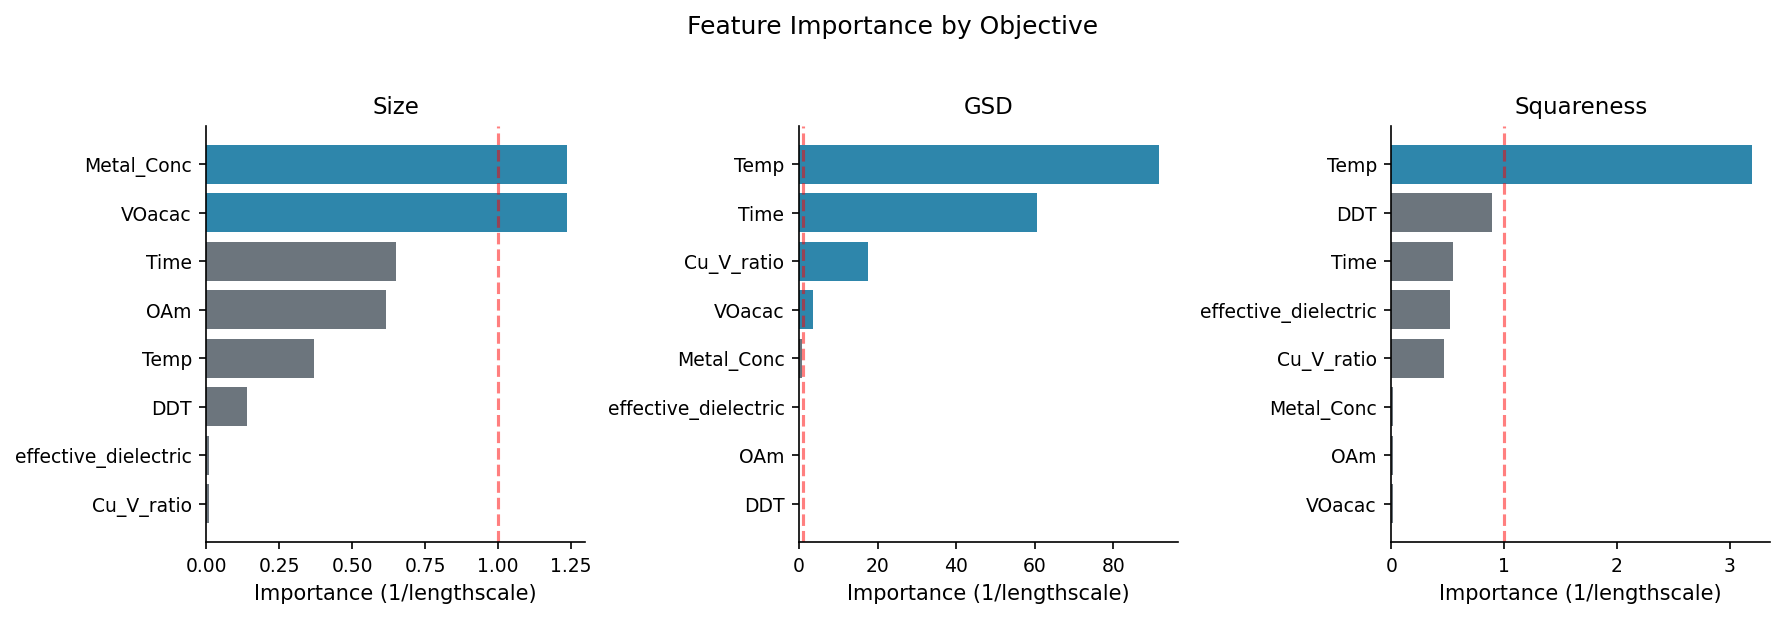

In [33]:
# =============================================================================
# LENGTHSCALE ANALYSIS
# =============================================================================

ls_df = model.get_lengthscales()

print("\n" + "=" * 70)
print("FEATURE IMPORTANCE (from GP lengthscales)")
print("=" * 70)
print("\nSmaller lengthscale = MORE important (function changes rapidly)")
print("Larger lengthscale = LESS important (function is flat)\n")

# Pivot for display
ls_pivot = ls_df.pivot(index='Feature', columns='Model', values='Lengthscale')
display(ls_pivot.round(2))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, obj in zip(axes, ['Size', 'GSD', 'Squareness']):
    data = ls_df[ls_df['Model'] == obj].sort_values('Importance', ascending=True)
    
    colors = [COLORS['primary'] if imp > 1 else COLORS['neutral'] 
              for imp in data['Importance']]
    
    ax.barh(data['Feature'], data['Importance'], color=colors)
    ax.set_xlabel('Importance (1/lengthscale)')
    ax.set_title(obj)
    ax.axvline(1.0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Feature Importance by Objective', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 9. Partial Dependence Analysis

These plots show *what the model learned* about how each feature affects the outcomes.


PARTIAL DEPENDENCE ANALYSIS


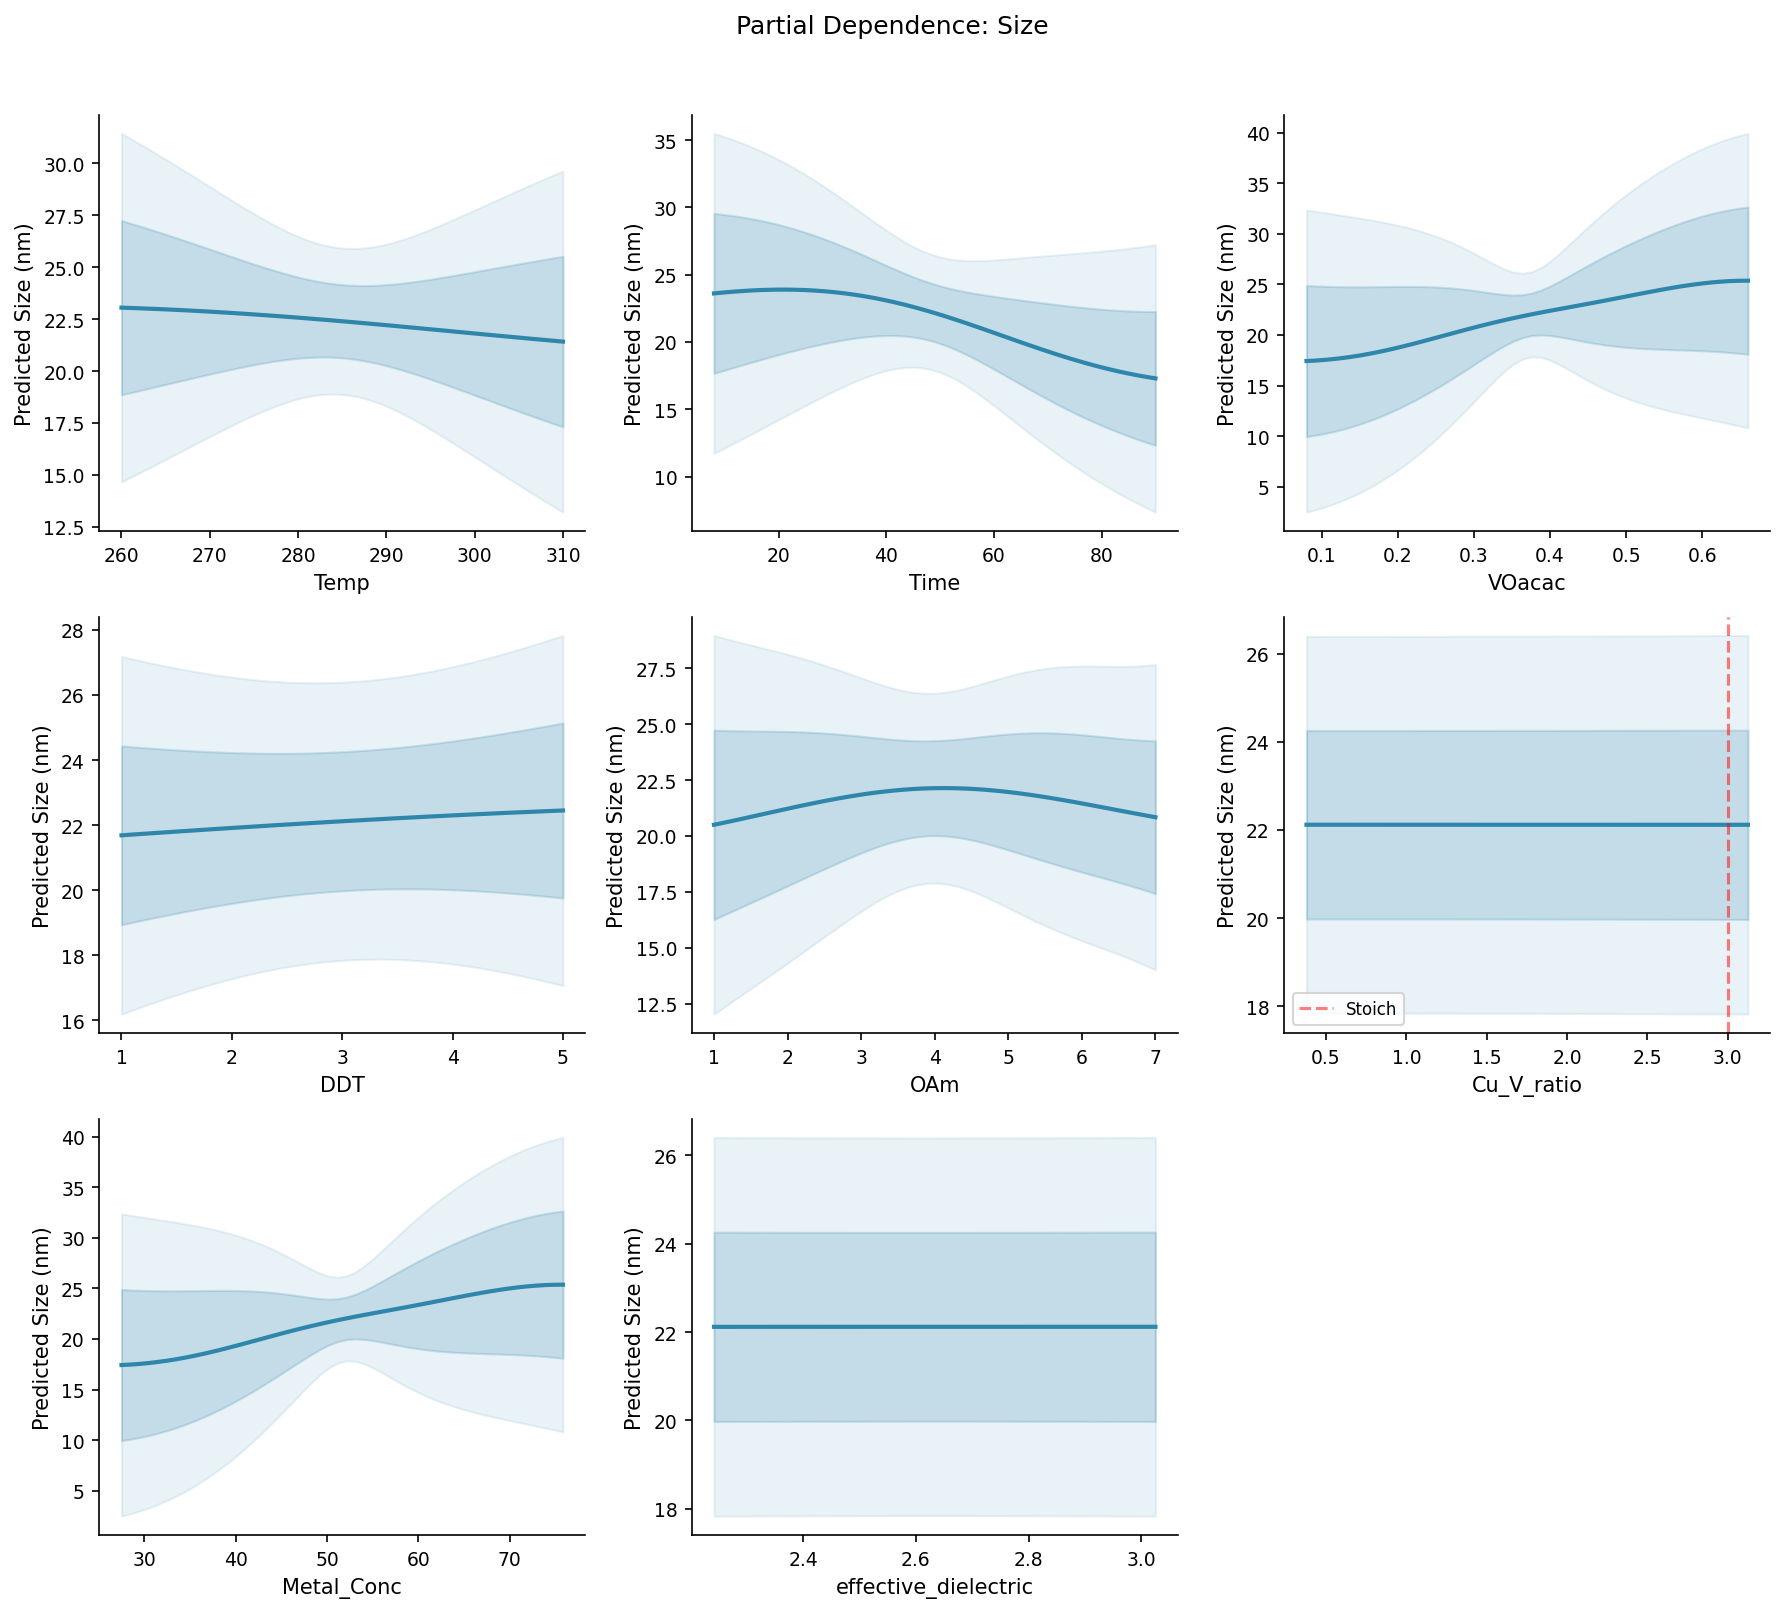


Interpretation:
  - Rising line: Higher feature value → larger particles
  - Falling line: Higher feature value → smaller particles
  - Flat line: Feature has little effect on size
  - Wide uncertainty band: Model is uncertain about this relationship


In [34]:
# =============================================================================
# PARTIAL DEPENDENCE PLOTS - SIZE
# =============================================================================

print("\n" + "=" * 70)
print("PARTIAL DEPENDENCE ANALYSIS")
print("=" * 70)

fig = plot_partial_dependence(model, target='size')
plt.savefig(OUTPUT_DIR / 'pdp_size.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Rising line: Higher feature value → larger particles")
print("  - Falling line: Higher feature value → smaller particles")
print("  - Flat line: Feature has little effect on size")
print("  - Wide uncertainty band: Model is uncertain about this relationship")

In [35]:
# =============================================================================
# VERIFY OBJECTIVE WEIGHTS (Optional check before optimization)
# =============================================================================

# Objective weights are automatically set in Cu3VS4Optimizer.__init__
# This cell is optional - just to verify weights are set correctly

print(f"\n✓ Model ready for optimization")
print(f"  Feature mode: {model.feature_mode}")
print(f"  Objective weights: {model.objective_weights}")
print(f"  Weights calculated automatically from data and model performance")


✓ Model ready for optimization
  Feature mode: hybrid
  Objective weights: {'GSD': 0.8324161800750008, 'Squareness': 1.1675838199249993}
  Weights calculated automatically from data and model performance


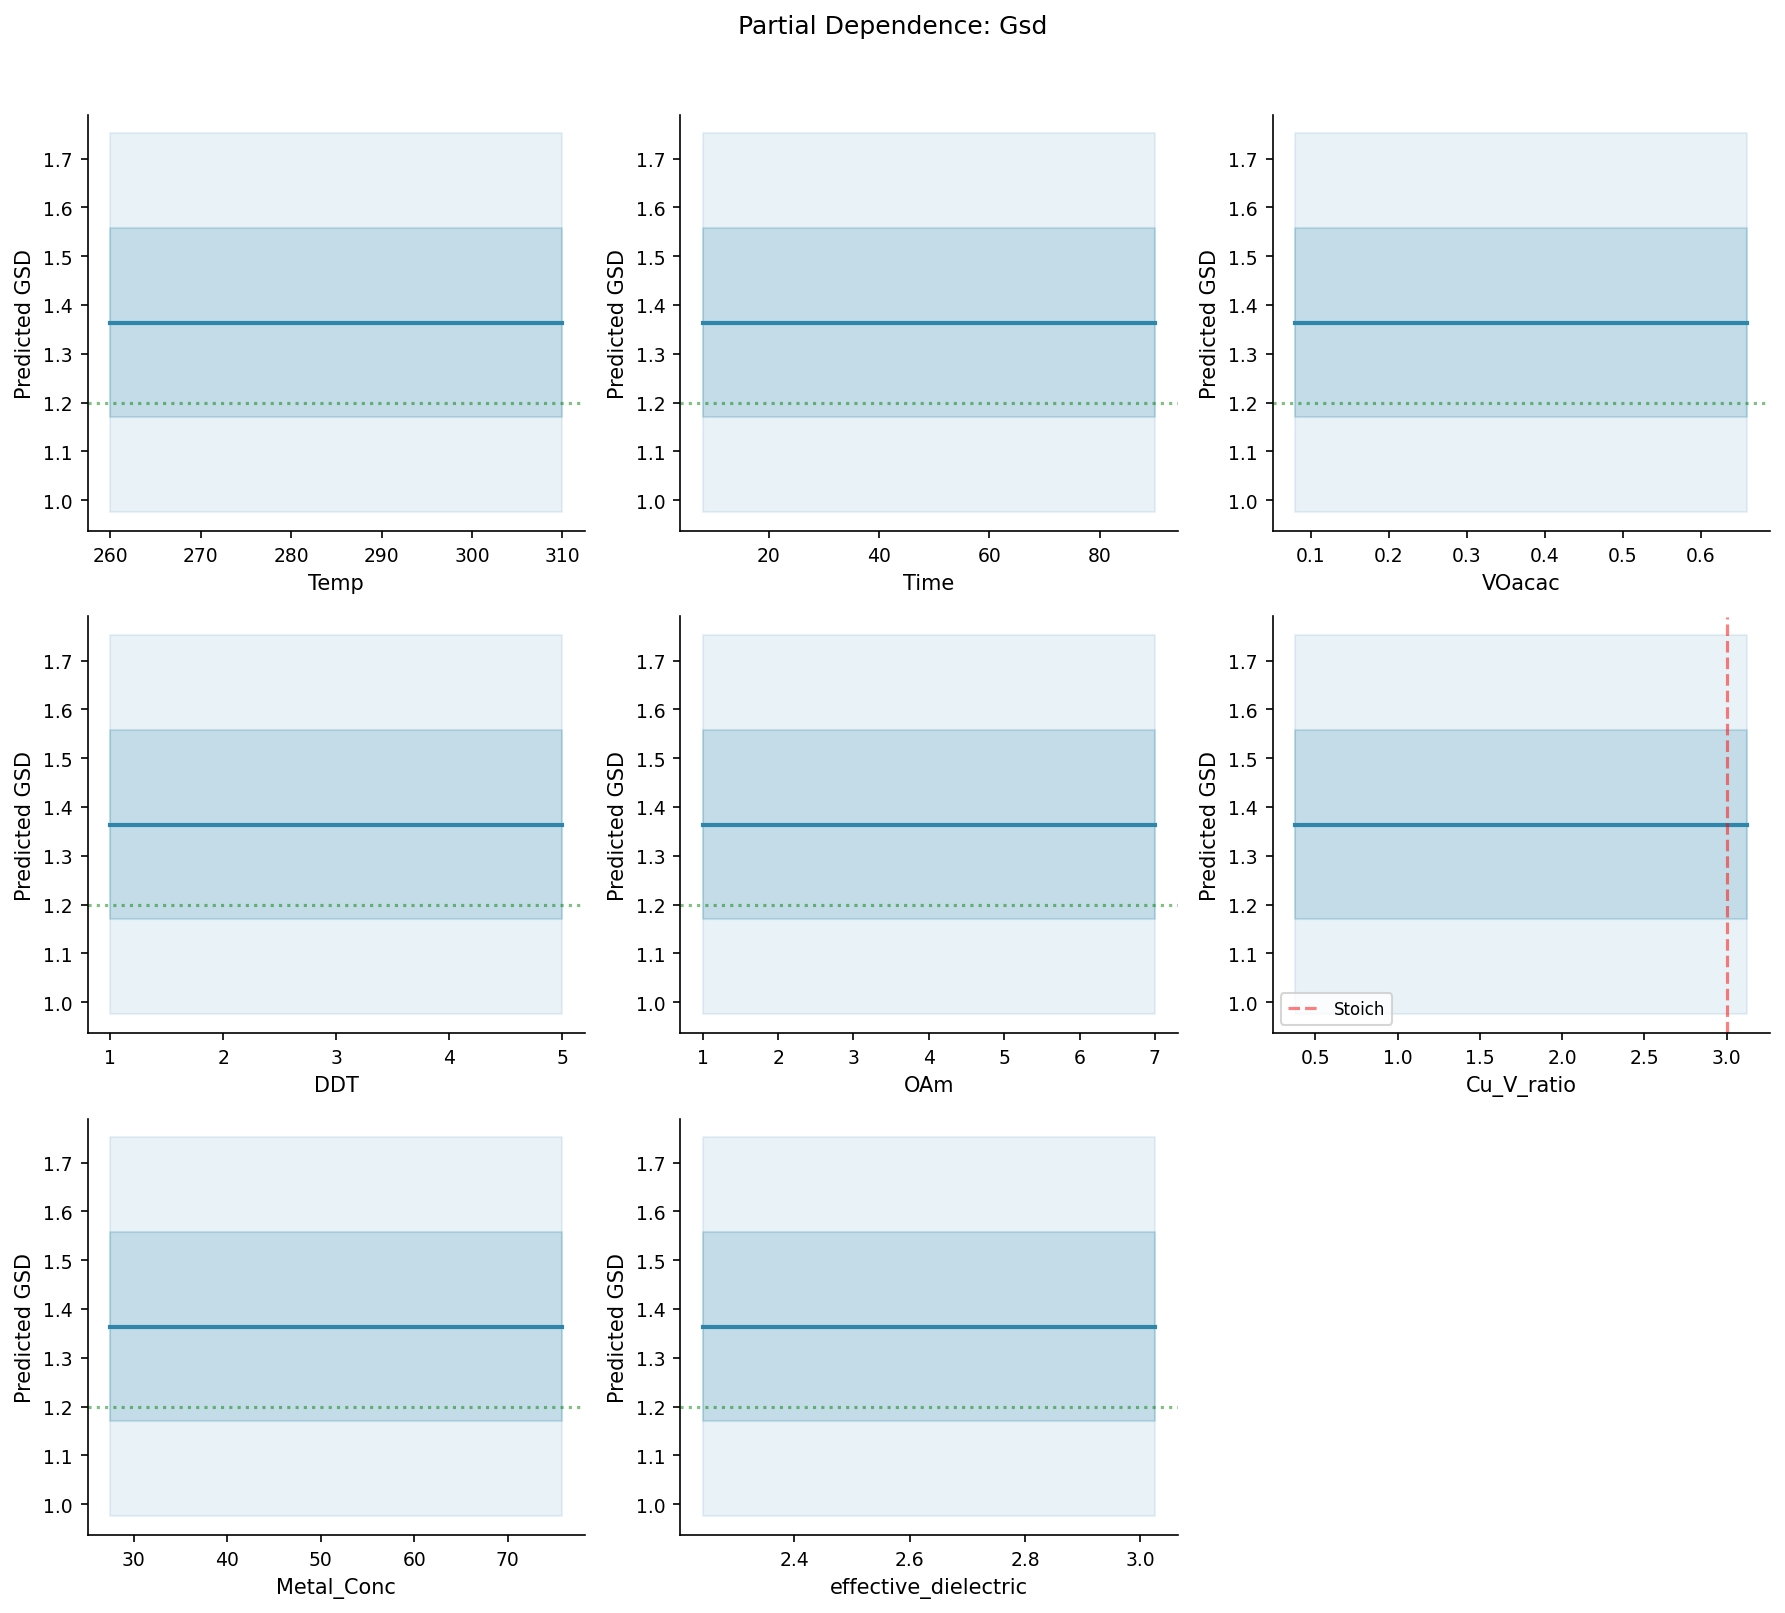


Interpretation for GSD (lower is better):
  - Falling line: Higher feature value → more monodisperse (GOOD)
  - Rising line: Higher feature value → more polydisperse (BAD)


In [36]:
# =============================================================================
# PARTIAL DEPENDENCE PLOTS - GSD
# =============================================================================

fig = plot_partial_dependence(model, target='gsd')
plt.savefig(OUTPUT_DIR / 'pdp_gsd.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation for GSD (lower is better):")
print("  - Falling line: Higher feature value → more monodisperse (GOOD)")
print("  - Rising line: Higher feature value → more polydisperse (BAD)")

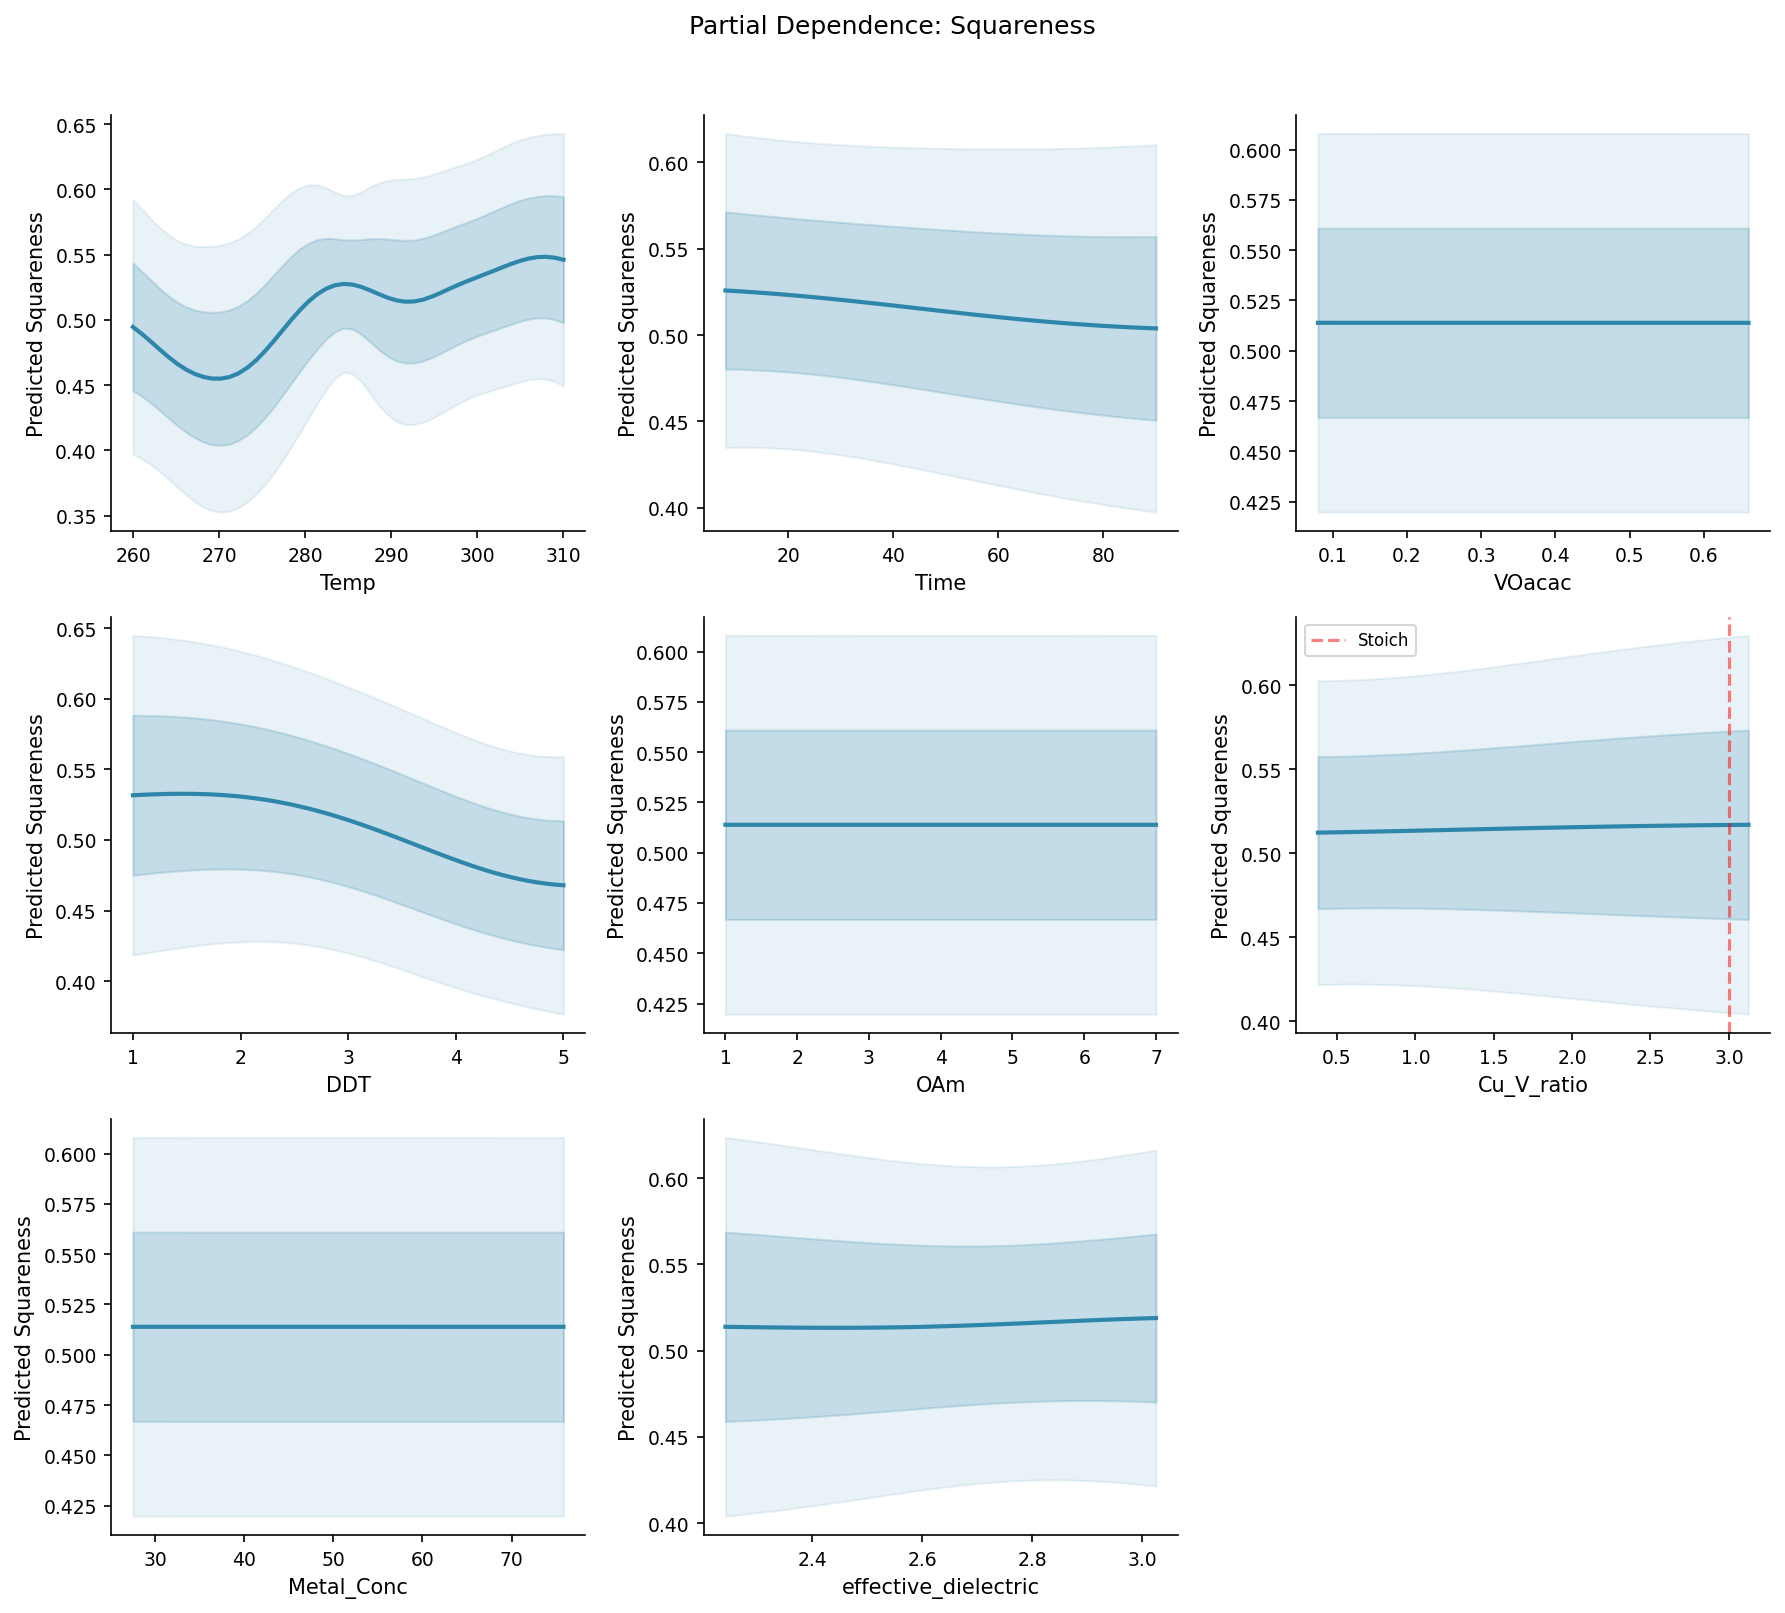


Interpretation for Squareness (higher is better):
  - Rising line: Higher feature value → more cubic (GOOD)
  - Falling line: Higher feature value → less cubic (BAD)


In [37]:
# =============================================================================
# PARTIAL DEPENDENCE PLOTS - SQUARENESS
# =============================================================================

fig = plot_partial_dependence(model, target='squareness')
plt.savefig(OUTPUT_DIR / 'pdp_squareness.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation for Squareness (higher is better):")
print("  - Rising line: Higher feature value → more cubic (GOOD)")
print("  - Falling line: Higher feature value → less cubic (BAD)")

---
## 10a. Predict Outcomes from Reaction Conditions

Input your synthesis conditions below to get model predictions for particle properties and feasibility.

In [38]:
# =============================================================================
# PREDICT OUTCOMES FROM REACTION CONDITIONS
# =============================================================================

def predict_from_conditions(
    Temp: float,
    Time: float,
    VOacac: float,
    DDT: float,
    OAm: float,
    model: Cu3VS4Optimizer = None,
    verbose: bool = True
) -> pd.DataFrame:
    """
    Predict nanoparticle properties from raw synthesis conditions.
    
    Parameters
    ----------
    Temp : float
        Temperature (°C)
    Time : float
        Reaction time (minutes)
    VOacac : float
        Vanadium precursor amount (mmol)
    DDT : float
        Dodecanethiol volume (mL)
    OAm : float
        Oleylamine volume (mL)
    model : Cu3VS4Optimizer, optional
        Model to use for predictions (defaults to global 'model')
    verbose : bool
        Print detailed results
    
    Returns
    -------
    DataFrame with predictions and feasibility probabilities
    """
    if model is None:
        if 'model' not in globals():
            raise ValueError("Model not found. Please ensure 'model' is defined or pass model explicitly.")
        model = globals()['model']
    
    # Create input array in the model's feature space
    # Compute chemical features (includes enhanced features if enabled)
    chem = raw_to_chemical_features(
        Temp=np.array([Temp]),
        Time=np.array([Time]),
        VOacac=np.array([VOacac]),
        DDT=np.array([DDT]),
        OAm=np.array([OAm])
    )
    
    if model.feature_mode == 'raw':
        X_input = np.array([[Temp, Time, VOacac, DDT, OAm]])
    elif model.feature_mode == 'chemical':
        # Chemical features only
        X_input = np.array([[chem['Cu_V_ratio'][0], chem['S_Metal_ratio'][0], 
                            chem['Ligand_Metal_ratio'][0], chem['Metal_Conc'][0], 
                            chem['log_Time'][0]]])
    elif model.feature_mode == 'hybrid':
        # Hybrid: raw + chemical features (dynamically includes enhanced features)
        feature_values = [Temp, Time, VOacac, DDT, OAm, 
                         chem['Cu_V_ratio'][0], chem['Metal_Conc'][0]]
        
        # Add enhanced features if they were included in model training
        if 'effective_dielectric' in chem:
            feature_values.append(chem['effective_dielectric'][0])
        if 'Cu_precursor_hardness' in chem:
            feature_values.append(chem['Cu_precursor_hardness'][0])
        if 'hsab_mismatch' in chem:
            feature_values.append(chem['hsab_mismatch'][0])
        if 'S_BDE' in chem:
            feature_values.append(chem['S_BDE'][0])
        
        X_input = np.array([feature_values])
    else:
        raise ValueError(f"Unknown feature_mode: {model.feature_mode}")
    
    # Get predictions
    preds = model.predict(X_input)
    
    # Create results dataframe
    results = pd.DataFrame({
        'Input_Conditions': {
            'Temp (°C)': f"{Temp:.1f}",
            'Time (min)': f"{Time:.1f}",
            'VOacac (mmol)': f"{VOacac:.3f}",
            'DDT (mL)': f"{DDT:.2f}",
            'OAm (mL)': f"{OAm:.2f}",
        },
        'Predicted_Properties': {
            'Size (nm)': f"{preds['size_mu'][0]:.2f} ± {preds['size_std'][0]:.2f}",
            'GSD': f"{preds['gsd_mu'][0]:.3f} ± {preds['gsd_std'][0]:.3f}",
            'Squareness': f"{preds['sq_mu'][0]:.3f} ± {preds['sq_std'][0]:.3f}",
        },
        'Feasibility_Probabilities': {
            'P(Product)': f"{preds['p_product'][0]:.3f}",
            'P(Phase Pure)': f"{preds['p_pure'][0]:.3f}",
            'P(Cubic)': f"{preds['p_cubic'][0]:.3f}",
            'P(Feasible)': f"{preds['p_feasible'][0]:.3f}",
        }
    })
    
    if verbose:
        print("=" * 70)
        print("PREDICTION RESULTS")
        print("=" * 70)
        print(f"\nInput Conditions:")
        print(f"  Temperature:     {Temp:.1f} °C")
        print(f"  Time:            {Time:.1f} min")
        print(f"  VOacac:          {VOacac:.3f} mmol")
        print(f"  DDT:             {DDT:.2f} mL")
        print(f"  OAm:             {OAm:.2f} mL")
        
        # Calculate chemical features for display (already computed above)
        print(f"\nDerived Chemical Features:")
        print(f"  Cu:V ratio:      {chem['Cu_V_ratio'][0]:.3f} (target = 3.0)")
        print(f"  Metal Conc:      {chem['Metal_Conc'][0]:.2f} mM")
        print(f"  S:Metal ratio:   {chem['S_Metal_ratio'][0]:.3f}")
        print(f"  Ligand:Metal:    {chem['Ligand_Metal_ratio'][0]:.3f}")
        # Display enhanced features if present
        if 'effective_dielectric' in chem:
            print(f"  Eff. Dielectric: {chem['effective_dielectric'][0]:.3f} (solvent polarity)")
        if 'Cu_precursor_hardness' in chem:
            print(f"  Cu Hardness:     {chem['Cu_precursor_hardness'][0]:.2f} eV (HSAB)")
        if 'hsab_mismatch' in chem:
            print(f"  HSAB Mismatch:   {chem['hsab_mismatch'][0]:.2f} eV")
        if 'S_BDE' in chem:
            print(f"  S Precursor BDE: {chem['S_BDE'][0]:.0f} kJ/mol")
        
        print(f"\nPredicted Properties:")
        print(f"  Size:           {preds['size_mu'][0]:.2f} ± {preds['size_std'][0]:.2f} nm")
        print(f"  GSD:            {preds['gsd_mu'][0]:.3f} ± {preds['gsd_std'][0]:.3f} (lower is better, ideal = 1.0)")
        print(f"  Squareness:     {preds['sq_mu'][0]:.3f} ± {preds['sq_std'][0]:.3f} (higher is better, ideal = 1.0)")
        
        print(f"\nFeasibility Probabilities:")
        print(f"  P(Product):     {preds['p_product'][0]:.3f}")
        print(f"  P(Phase Pure):  {preds['p_pure'][0]:.3f}")
        print(f"  P(Cubic):       {preds['p_cubic'][0]:.3f}")
        print(f"  P(Feasible):    {preds['p_feasible'][0]:.3f} (combined)")
        
        # Interpretation
        print(f"\nInterpretation:")
        if preds['p_feasible'][0] > 0.7:
            print(f"  ✓ High feasibility - good chance of success")
        elif preds['p_feasible'][0] > 0.4:
            print(f"  ⚠ Moderate feasibility - may work but uncertain")
        else:
            print(f"  ✗ Low feasibility - unlikely to succeed")
        
        if preds['gsd_mu'][0] < 1.2:
            print(f"  ✓ Predicted GSD is good (monodisperse)")
        elif preds['gsd_mu'][0] < 1.4:
            print(f"  ⚠ Predicted GSD is moderate")
        else:
            print(f"  ✗ Predicted GSD is high (polydisperse)")
        
        if preds['sq_mu'][0] > 0.8:
            print(f"  ✓ Predicted squareness is good (cubic)")
        elif preds['sq_mu'][0] > 0.6:
            print(f"  ⚠ Predicted squareness is moderate")
        else:
            print(f"  ✗ Predicted squareness is low (non-cubic)")
        
        print("=" * 70)
    
    return results


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

# Example 1: Predict for specific conditions
# Uncomment and modify these values to test your own conditions:

# result = predict_from_conditions(
#     Temp=280.0,      # Temperature in °C
#     Time=30.0,        # Time in minutes
#     VOacac=0.15,      # Vanadium precursor (mmol)
#     DDT=3.0,          # Dodecanethiol (mL)
#     OAm=4.0,          # Oleylamine (mL)
#     model=model,      # Use the trained model
#     verbose=True
# )

# Example 2: Batch prediction for multiple conditions
def predict_batch(conditions_list: List[Dict[str, float]], model: Cu3VS4Optimizer = None) -> pd.DataFrame:
    """
    Predict outcomes for multiple reaction conditions.
    
    Parameters
    ----------
    conditions_list : list of dicts
        Each dict should have keys: 'Temp', 'Time', 'VOacac', 'DDT', 'OAm'
    model : Cu3VS4Optimizer, optional
        Model to use (defaults to global 'model')
    
    Returns
    -------
    DataFrame with predictions for all conditions
    """
    if model is None:
        model = globals()['model']
    
    results = []
    for i, cond in enumerate(conditions_list):
        # Convert to model's feature space (same logic as predict_from_conditions)
        chem = raw_to_chemical_features(
            Temp=np.array([cond['Temp']]),
            Time=np.array([cond['Time']]),
            VOacac=np.array([cond['VOacac']]),
            DDT=np.array([cond['DDT']]),
            OAm=np.array([cond['OAm']])
        )
        
        if model.feature_mode == 'raw':
            X_input = np.array([[cond['Temp'], cond['Time'], cond['VOacac'], cond['DDT'], cond['OAm']]])
        elif model.feature_mode == 'chemical':
            X_input = np.array([[chem['Cu_V_ratio'][0], chem['S_Metal_ratio'][0], 
                                chem['Ligand_Metal_ratio'][0], chem['Metal_Conc'][0], 
                                chem['log_Time'][0]]])
        elif model.feature_mode == 'hybrid':
            # Build feature list dynamically including enhanced features
            feature_values = [cond['Temp'], cond['Time'], cond['VOacac'], cond['DDT'], cond['OAm'], 
                             chem['Cu_V_ratio'][0], chem['Metal_Conc'][0]]
            
            # Add enhanced features if they were included in model training
            if 'effective_dielectric' in chem:
                feature_values.append(chem['effective_dielectric'][0])
            if 'Cu_precursor_hardness' in chem:
                feature_values.append(chem['Cu_precursor_hardness'][0])
            if 'hsab_mismatch' in chem:
                feature_values.append(chem['hsab_mismatch'][0])
            if 'S_BDE' in chem:
                feature_values.append(chem['S_BDE'][0])
            
            X_input = np.array([feature_values])
        else:
            raise ValueError(f"Unknown feature_mode: {model.feature_mode}")
        
        # Get predictions
        pred_dict = model.predict(X_input)
        
        results.append({
            'Condition_ID': i + 1,
            'Temp': cond['Temp'],
            'Time': cond['Time'],
            'VOacac': cond['VOacac'],
            'DDT': cond['DDT'],
            'OAm': cond['OAm'],
            'Pred_Size': pred_dict['size_mu'][0],
            'Pred_Size_Std': pred_dict['size_std'][0],
            'Pred_GSD': pred_dict['gsd_mu'][0],
            'Pred_GSD_Std': pred_dict['gsd_std'][0],
            'Pred_Squareness': pred_dict['sq_mu'][0],
            'Pred_Squareness_Std': pred_dict['sq_std'][0],
            'P_Product': pred_dict['p_product'][0],
            'P_Pure': pred_dict['p_pure'][0],
            'P_Cubic': pred_dict['p_cubic'][0],
            'P_Feasible': pred_dict['p_feasible'][0],
        })
    
    return pd.DataFrame(results)

# Example batch usage:
# conditions = [
#     {'Temp': 280.0, 'Time': 30.0, 'VOacac': 0.15, 'DDT': 3.0, 'OAm': 4.0},
#     {'Temp': 290.0, 'Time': 45.0, 'VOacac': 0.20, 'DDT': 3.5, 'OAm': 5.0},
# ]
# batch_results = predict_batch(conditions, model=model)
# display(batch_results)

print("✓ Prediction functions loaded!")
print("\nTo use:")
print("  1. Call predict_from_conditions(Temp, Time, VOacac, DDT, OAm)")
print("  2. Or use predict_batch() for multiple conditions")
print("\nSee examples in the code above (uncomment to run).")

✓ Prediction functions loaded!

To use:
  1. Call predict_from_conditions(Temp, Time, VOacac, DDT, OAm)
  2. Or use predict_batch() for multiple conditions

See examples in the code above (uncomment to run).


In [39]:
result = predict_from_conditions(
    Temp=297.0,      # Temperature in °C
    Time=14.0,        # Time in minutes
    VOacac=0.594,      # Vanadium precursor (mmol)
    DDT=2.3,          # Dodecanethiol (mL)
    OAm=6.2,          # Oleylamine (mL)
    model=model,
    verbose=True
)

PREDICTION RESULTS

Input Conditions:
  Temperature:     297.0 °C
  Time:            14.0 min
  VOacac:          0.594 mmol
  DDT:             2.30 mL
  OAm:             6.20 mL

Derived Chemical Features:
  Cu:V ratio:      0.421 (target = 3.0)
  Metal Conc:      70.33 mM
  S:Metal ratio:   11.364
  Ligand:Metal:    22.332
  Eff. Dielectric: 2.848 (solvent polarity)

Predicted Properties:
  Size:           18.97 ± 1.84 nm
  GSD:            1.269 ± 0.150 (lower is better, ideal = 1.0)
  Squareness:     0.553 ± 0.034 (higher is better, ideal = 1.0)

Feasibility Probabilities:
  P(Product):     0.909
  P(Phase Pure):  0.728
  P(Cubic):       0.825
  P(Feasible):    0.545 (combined)

Interpretation:
  ⚠ Moderate feasibility - may work but uncertain
  ⚠ Predicted GSD is moderate
  ✗ Predicted squareness is low (non-cubic)


---
## 10. Optimization

In [40]:
# =============================================================================
# SINGLE TARGET OPTIMIZATION
# =============================================================================

TARGET_SIZE = 18.242
SIZE_TOL = 1.0

print(f"\n" + "=" * 70)
print(f"OPTIMIZATION: Target {TARGET_SIZE} ± {SIZE_TOL} nm")
print("=" * 70)

recommendations = model.recommend(
    target_size=TARGET_SIZE,
    size_tol=SIZE_TOL,
    p_size_min=0.15,
    p_feas_min=0.25,
    n_candidates=25000,
    n_return=2,
    seed=42
)

print("\nRecommended Conditions:")
display(recommendations)


OPTIMIZATION: Target 18.242 ± 1.0 nm

Recommended Conditions:


,Rank,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_Squareness,P_Size,P_Feasible,Acquisition
0,1,309.316,19.169,0.239,2.027,3.263,18.59,4.88,1.363,0.581,0.162,0.671,0.0871
1,2,309.035,66.796,0.135,2.367,1.764,16.84,4.49,1.363,0.569,0.168,0.582,0.0709


In [41]:
# =============================================================================
# SIZE SWEEP
# =============================================================================

print("\n" + "=" * 70)
print("SIZE SWEEP OPTIMIZATION")
print("=" * 70)

size_targets = [12, 15, 18, 20, 25, 30]
sweep_results = []

for target in size_targets:
    try:
        recs = model.recommend(
            target_size=target,
            size_tol=2.5,
            p_size_min=0.10,
            p_feas_min=0.20,
            n_candidates=15000,
            n_return=1,
            seed=42
        )
        if len(recs) > 0:
            row = recs.iloc[0].to_dict()
            row['Target'] = target
            sweep_results.append(row)
            print(f"  {target}nm: Pred={row['Pred_Size']:.1f}nm, GSD={row['Pred_GSD']:.3f}")
    except Exception as e:
        print(f"  {target}nm: Failed - {e}")

sweep_df = pd.DataFrame(sweep_results)
print("\nFull sweep results:")
display(sweep_df)


SIZE SWEEP OPTIMIZATION
  12nm: Pred=13.3nm, GSD=1.363
  15nm: Pred=13.3nm, GSD=1.363
  18nm: Pred=18.6nm, GSD=1.363
  20nm: Pred=20.1nm, GSD=1.363
  25nm: Pred=24.7nm, GSD=1.363
  30nm: Pred=27.8nm, GSD=1.363

Full sweep results:


,Rank,Temp,Time,VOacac,DDT,OAm,Pred_Size,Pred_Size_Std,Pred_GSD,Pred_Squareness,P_Size,P_Feasible,Acquisition,Target
0,1.0,309.030,36.069,0.137,2.217,3.157,13.31,4.96,1.363,0.576,0.374,0.594,0.1250,12
1,1.0,309.030,36.069,0.137,2.217,3.157,13.31,4.96,1.363,0.576,0.366,0.594,0.1224,15
2,1.0,309.198,85.191,0.152,2.204,1.632,18.57,4.04,1.363,0.563,0.460,0.619,0.1044,18
3,1.0,307.808,51.093,0.323,1.826,3.669,20.14,4.02,1.363,0.578,0.466,0.425,0.1121,20
4,1.0,309.419,55.844,0.576,1.970,4.841,24.73,4.88,1.363,0.576,0.391,0.592,0.1238,25
5,1.0,308.231,37.159,0.527,2.185,3.075,27.76,5.69,1.363,0.576,0.316,0.526,0.0937,30


---
## 11. Parity Plots

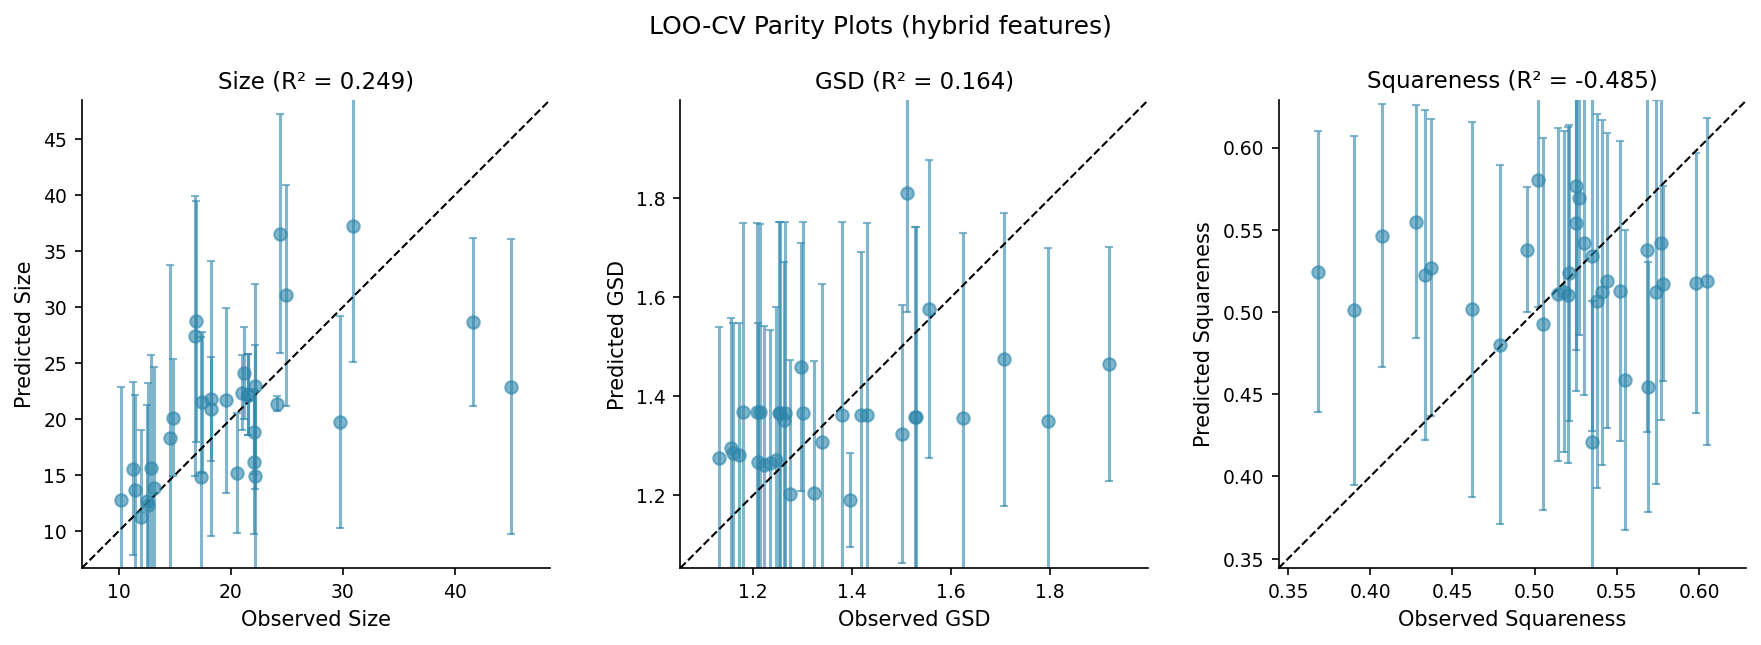

In [42]:
# =============================================================================
# PARITY PLOTS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, name in zip(axes, ['Size', 'GSD', 'Squareness']):
    y_true = model.df_success[name].values
    y_pred = model.metrics[name]['y_pred']
    y_std = model.metrics[name]['y_std']
    r2 = model.metrics[name]['r2']
    
    ax.errorbar(y_true, y_pred, yerr=1.96*y_std, fmt='o', alpha=0.6,
                capsize=2, markersize=6, color=COLORS['primary'])
    
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    margin = 0.1 * (lims[1] - lims[0])
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'k--', lw=1)
    
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(f'Observed {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(f'{name} (R² = {r2:.3f})')
    ax.set_aspect('equal')

plt.suptitle(f'LOO-CV Parity Plots ({model.feature_mode} features)', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'parity_plots.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 12. Export Results

In [43]:
# =============================================================================
# SAVE RESULTS
# =============================================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Recommendations
rec_path = OUTPUT_DIR / f"recommendations_{TARGET_SIZE}nm_{timestamp}.csv"
recommendations.to_csv(rec_path, index=False)
print(f"Saved: {rec_path}")

# Sweep
if len(sweep_df) > 0:
    sweep_path = OUTPUT_DIR / f"size_sweep_{timestamp}.csv"
    sweep_df.to_csv(sweep_path, index=False)
    print(f"Saved: {sweep_path}")

# Model comparison
comp_path = OUTPUT_DIR / f"model_comparison_{timestamp}.csv"
comparison_df.to_csv(comp_path, index=False)
print(f"Saved: {comp_path}")

# Feature importance
feat_path = OUTPUT_DIR / f"feature_importance_{timestamp}.csv"
ls_df.to_csv(feat_path, index=False)
print(f"Saved: {feat_path}")

Saved: ../Outputs/recommendations_18.242nm_20260121_154955.csv
Saved: ../Outputs/size_sweep_20260121_154955.csv
Saved: ../Outputs/model_comparison_20260121_154955.csv
Saved: ../Outputs/feature_importance_20260121_154955.csv


In [44]:
# =============================================================================
# SESSION SUMMARY
# =============================================================================

print("\n" + "=" * 70)
print("SESSION SUMMARY")
print("=" * 70)
print(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"\nData:")
print(f"  Total experiments: {len(df)}")
print(f"  Successful: {len(df_success)}")
print(f"\nModel:")
print(f"  Feature mode: {model.feature_mode}")
print(f"  Features: {model.features}")
print(f"\nSystem constants:")
print(f"  CuI: {CUI_MMOL} mmol")
print(f"  Total volume: {TOTAL_VOLUME_ML} mL")
print(f"\nObjective weights:")
if hasattr(model, 'objective_weights') and model.objective_weights is not None:
    print(f"  GSD: {model.objective_weights.get('GSD', 'N/A')}")
    print(f"  Squareness: {model.objective_weights.get('Squareness', 'N/A')}")
    print(f"  (Calculated statistically from data and model performance)")
elif OBJECTIVE_WEIGHTS is not None:
    print(f"  GSD: {OBJECTIVE_WEIGHTS.get('GSD', 'N/A')}")
    print(f"  Squareness: {OBJECTIVE_WEIGHTS.get('Squareness', 'N/A')}")
    print(f"  (Manual weights)")
else:
    print(f"  GSD: 1.0 (default)")
    print(f"  Squareness: 1.0 (default)")
    print(f"  (Weights not calculated - using defaults)")


SESSION SUMMARY
Date: 2026-01-21 15:49:55

Data:
  Total experiments: 43
  Successful: 33

Model:
  Feature mode: hybrid
  Features: ['Temp', 'Time', 'VOacac', 'DDT', 'OAm', 'Cu_V_ratio', 'Metal_Conc', 'effective_dielectric']

System constants:
  CuI: 0.25 mmol
  Total volume: 12.0 mL

Objective weights:
  GSD: 0.8324161800750008
  Squareness: 1.1675838199249993
  (Calculated statistically from data and model performance)
